In [1]:
import pandas as pd
import numpy as np

In [2]:
# Dictionary containing dataset names and date columns
data_files = {
    "sessions": ["session_time"],
    "trips": ["pickup_time", "dropoff_time"],
    "riders": ["signup_date"],
    "drivers": ["signup_date", "last_active"],
    "promotions": ["start_date", "end_date"]
}

# Dictionary to store DataFrames
dfs = {}

In [5]:
# Load all datasets
for name, date_cols in data_files.items():
    dfs[name] = pd.read_csv(
        f"../data/raw/{name}.csv",
        parse_dates=date_cols
    )

# Assign DataFrames to variables
sessions = dfs["sessions"]
trips = dfs["trips"]
riders = dfs["riders"]
drivers = dfs["drivers"]
promotions = dfs["promotions"]

EDA FOR riders

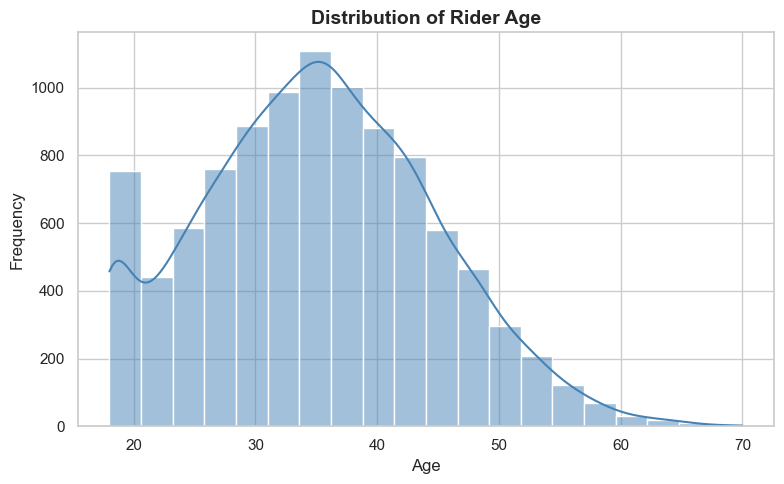

In [6]:
# Import Required Libraries

import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")


# Distribution of Rider Age

plt.figure(figsize=(8, 5))

sns.histplot(
    data=riders,
    x="age",
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Rider Age", fontsize=14, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

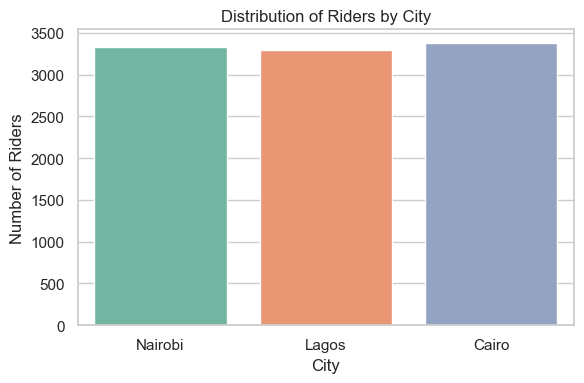

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=riders,
    x="city",
    hue="city",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Riders by City")
plt.xlabel("City")
plt.ylabel("Number of Riders")

plt.tight_layout()
plt.show()

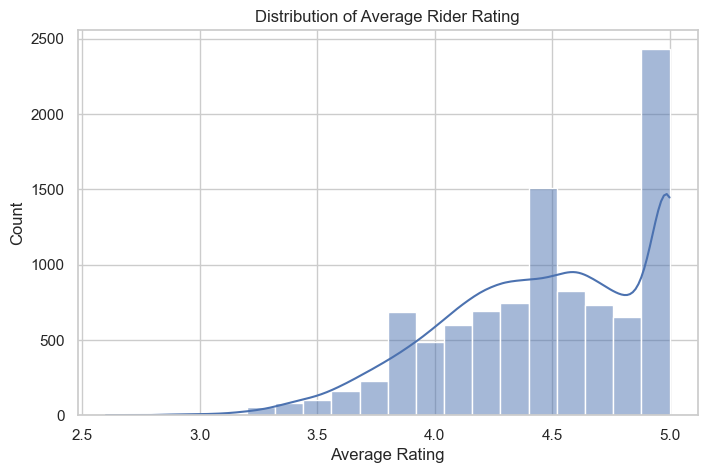

In [ ]:
# distribution of average rider rating
plt.figure(figsize=(8, 5))

sns.histplot(
    data=riders,
    x="avg_rating_given",
    bins=20,
    kde=True
)

plt.title("Distribution of Average Rider Rating")
plt.xlabel("Average Rating")
plt.ylabel("Count")

plt.show()

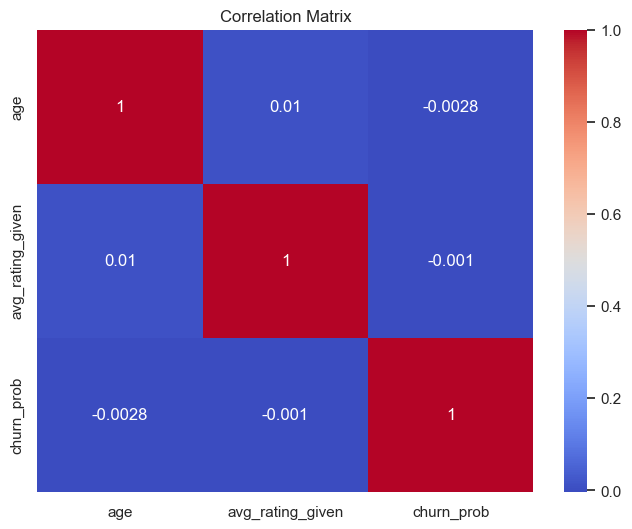

In [18]:
numeric = riders.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

Business Insights (Document These)


Most riders belong to the 25–45 age group.
The rider base is reasonably balanced by gender (or note any imbalance).
One or two cities contribute the largest share of riders.
Most customers use a particular payment method.
Rider ratings are generally high, indicating good service satisfaction.
Loyalty tiers are concentrated in entry-level members, suggesting opportunities to increase retention and engagement.

In [21]:
numerical_cols_riders = riders.select_dtypes(
    include=["int64", "float64"]
).columns

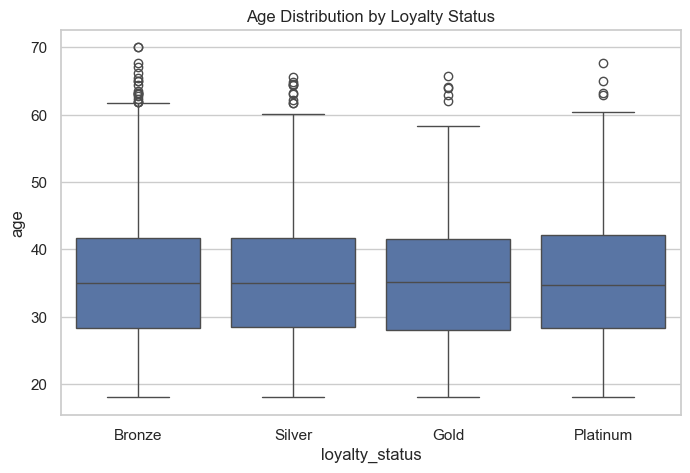

In [ ]:

# Age Distribution by Loyalty Status
# Purpose:
# Compare the distribution of rider ages across
# different loyalty categories.

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=dfs["riders"],
    x="loyalty_status",
    y="age"
)

plt.title("Age Distribution by Loyalty Status")

plt.show()

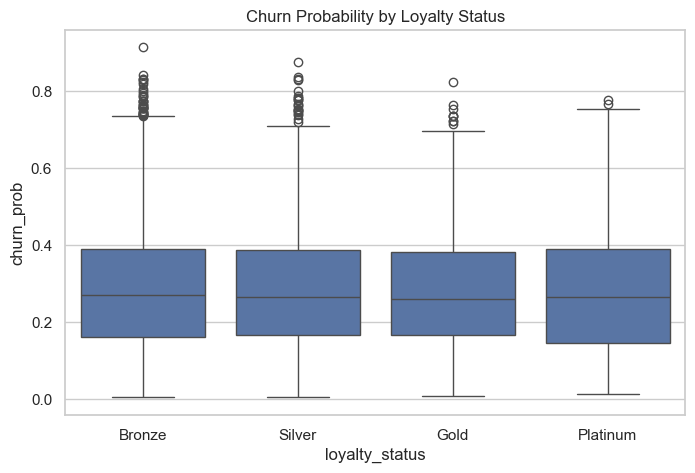

In [24]:

# Churn Probability by Loyalty Status
# Purpose:
# Compare churn probability across loyalty groups
# to identify customer retention patterns.


plt.figure(figsize=(8, 5))

sns.boxplot(
    data=dfs["riders"],
    x="loyalty_status",
    y="churn_prob"
)

plt.title("Churn Probability by Loyalty Status")

plt.show()

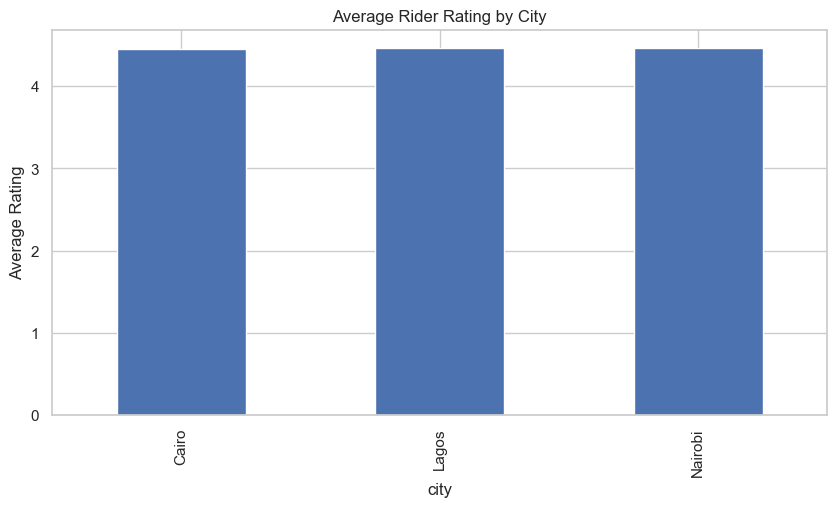

In [25]:

# Average Rider Rating by City
# Purpose:
# Calculate and visualise the average rider rating
# for each city.


plt.figure(figsize=(10, 5))

city_rating = (
    dfs["riders"]
    .groupby("city")["avg_rating_given"]
    .mean()
    .sort_values()
)

city_rating.plot(kind="bar")

plt.title("Average Rider Rating by City")

plt.ylabel("Average Rating")

plt.show()

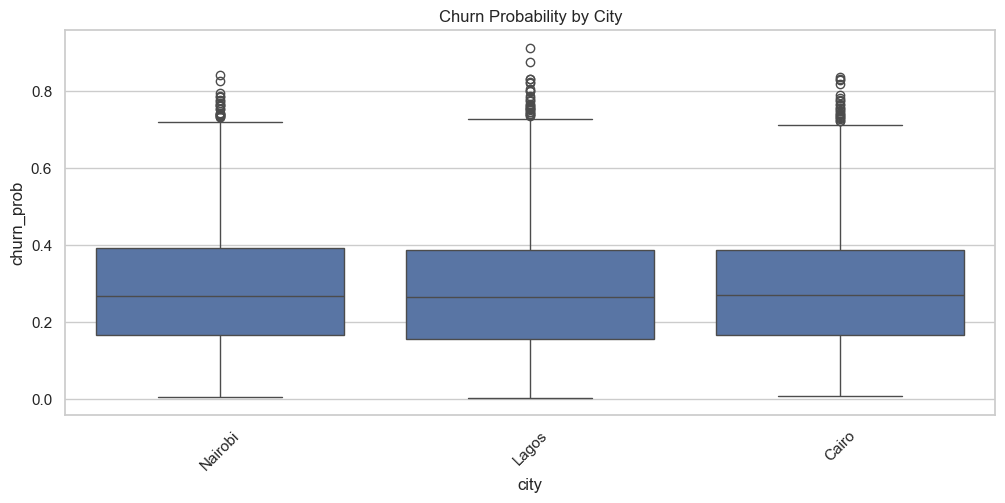

In [ ]:

# Churn Probability by City
# Purpose:
# Compare churn probability across different cities.


plt.figure(figsize=(12, 5))

sns.boxplot(
    data=dfs["riders"],
    x="city",
    y="churn_prob"
)

plt.xticks(rotation=45)

plt.title("Churn Probability by City")

plt.show()

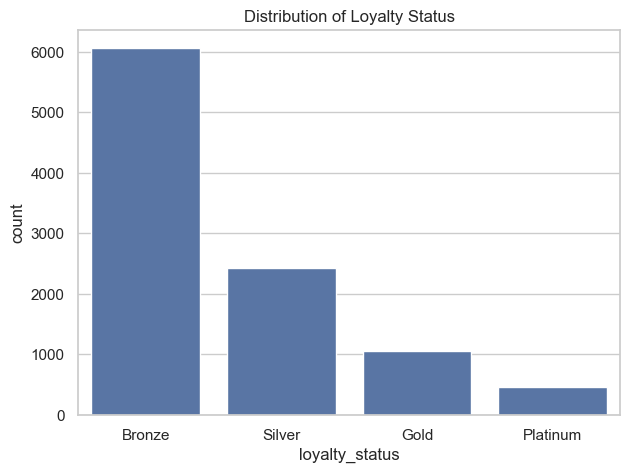

In [27]:

# Loyalty Status Distribution
# Purpose:
# Show the frequency of each loyalty category.


plt.figure(figsize=(7, 5))

sns.countplot(
    data=dfs["riders"],
    x="loyalty_status"
)

plt.title("Distribution of Loyalty Status")

plt.show()

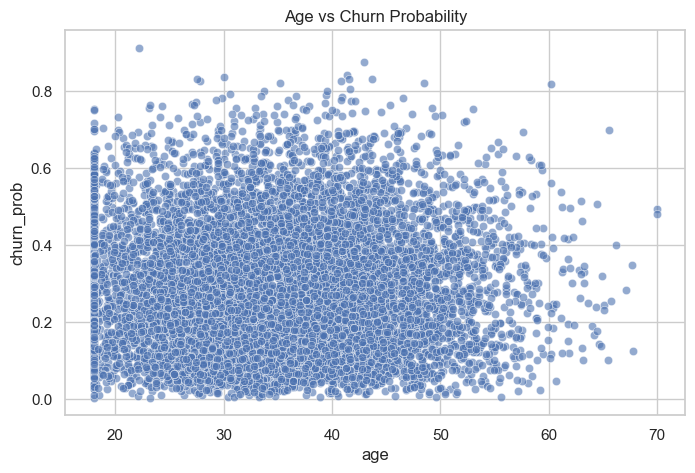

In [28]:

# Scatter Plot: Age vs Churn Probability
# Purpose:
# Explore the relationship between rider age
# and predicted churn probability.

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=dfs["riders"],
    x="age",
    y="churn_prob",
    alpha=0.6
)

plt.title("Age vs Churn Probability")

plt.show()

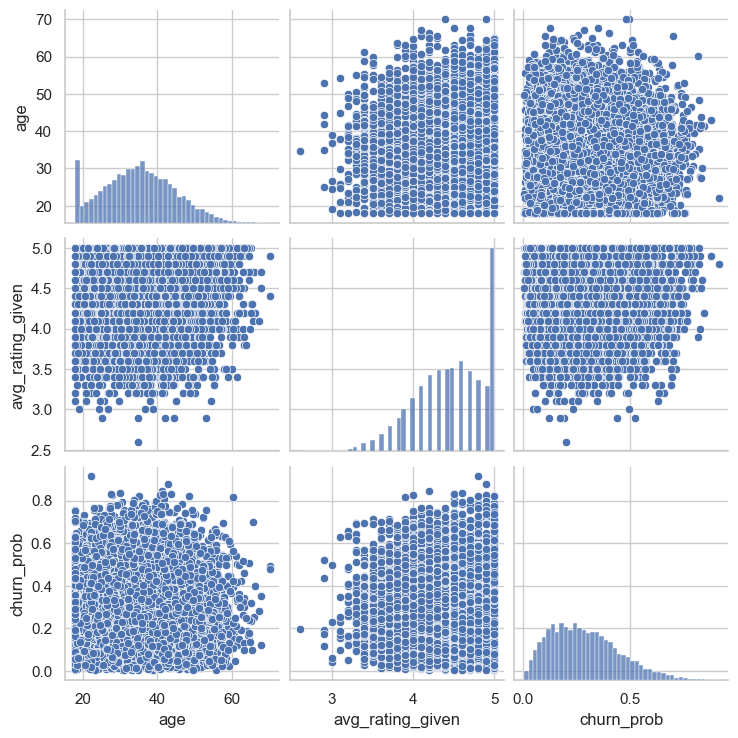

In [29]:

# Pair Plot
# Purpose:
# Examine pairwise relationships between all
# numerical variables.

sns.pairplot(
    dfs["riders"][numerical_cols_riders]
)

plt.show()

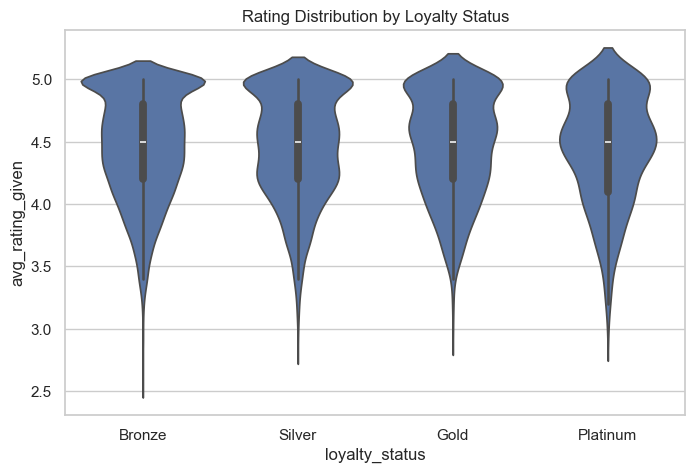

In [30]:

# Violin Plot
# Purpose:
# Compare the distribution of rider ratings
# across loyalty categories.


plt.figure(figsize=(8, 5))

sns.violinplot(
    data=dfs["riders"],
    x="loyalty_status",
    y="avg_rating_given"
)

plt.title("Rating Distribution by Loyalty Status")

plt.show()

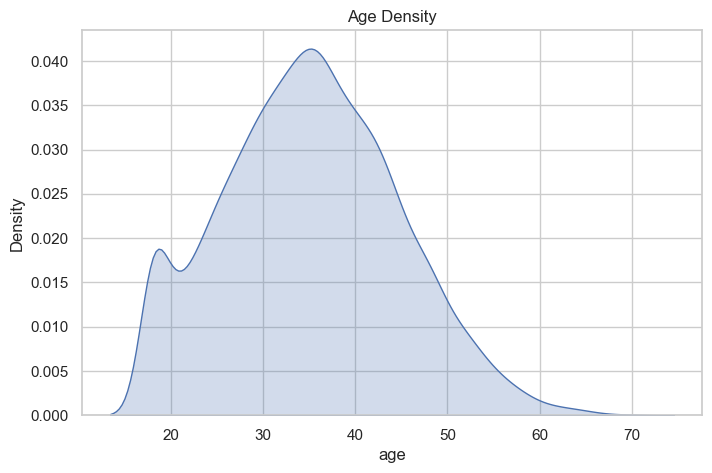

In [31]:

# Kernel Density Estimate (KDE)
# Purpose:
# Visualise the probability density of rider ages.


plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=dfs["riders"],
    x="age",
    fill=True
)

plt.title("Age Density")

plt.show()

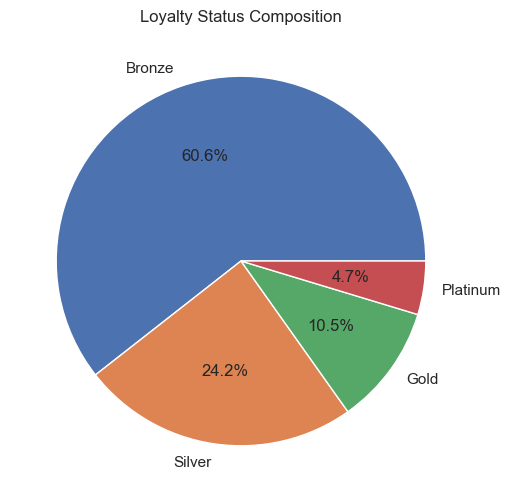

In [32]:

# Loyalty Status Composition
# Purpose:
# Show the percentage composition of each
# loyalty category.


dfs["riders"]["loyalty_status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6, 6)
)

plt.ylabel("")

plt.title("Loyalty Status Composition")

plt.show()

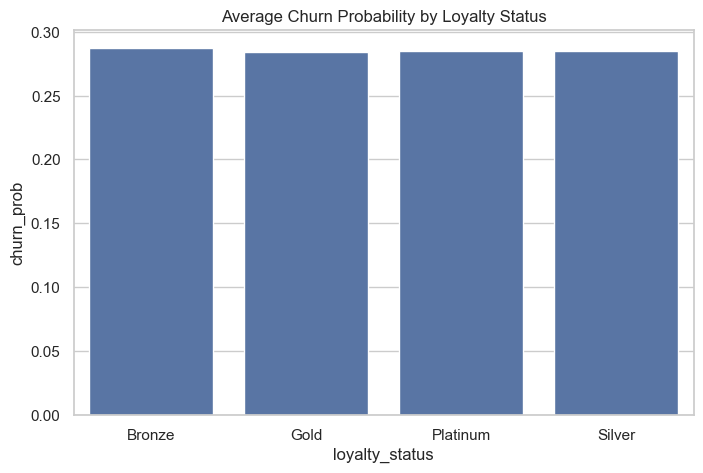

In [33]:

# Average Churn Probability by Loyalty Status
# Purpose:
# Compare the average churn probability
# for each loyalty group.


plt.figure(figsize=(8, 5))

mean_churn = (
    dfs["riders"]
    .groupby("loyalty_status")["churn_prob"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=mean_churn,
    x="loyalty_status",
    y="churn_prob"
)

plt.title("Average Churn Probability by Loyalty Status")

plt.show()

EDA FOR Sessions

In [37]:
print(sessions.columns.tolist())

['session_id', 'rider_id', 'session_time', 'time_on_app', 'pages_visited', 'converted', 'city', 'loyalty_status']


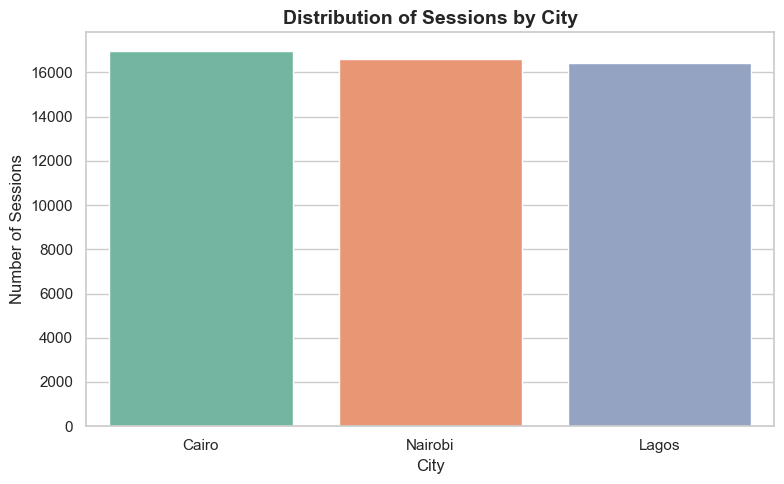

In [39]:
# =====================================================
# Distribution of Sessions by City
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Apply a clean visual theme
sns.set_theme(style="whitegrid")

# Create a plotting canvas
plt.figure(figsize=(8, 5))

# Plot the number of sessions recorded in each city
sns.countplot(
    data=sessions,
    x="city",
    hue="city",          # Assign hue to avoid seaborn deprecation warning
    palette="Set2",
    legend=False
)

# Add chart title and axis labels
plt.title("Distribution of Sessions by City", fontsize=14, fontweight="bold")
plt.xlabel("City")
plt.ylabel("Number of Sessions")

# Ensure labels fit neatly within the figure
plt.tight_layout()

# Display the chart
plt.show()

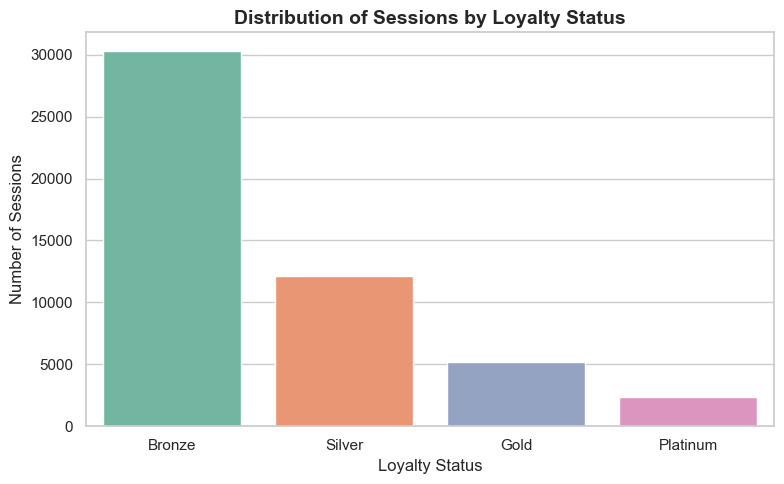

In [40]:
# =====================================================
# Distribution of Sessions by Loyalty Status
# =====================================================

# Create a plotting canvas
plt.figure(figsize=(8, 5))

# Plot the number of sessions for each loyalty tier
sns.countplot(
    data=sessions,
    x="loyalty_status",
    hue="loyalty_status",
    palette="Set2",
    legend=False
)

# Add chart title and axis labels
plt.title("Distribution of Sessions by Loyalty Status", fontsize=14, fontweight="bold")
plt.xlabel("Loyalty Status")
plt.ylabel("Number of Sessions")

# Adjust layout
plt.tight_layout()

# Display the chart
plt.show()

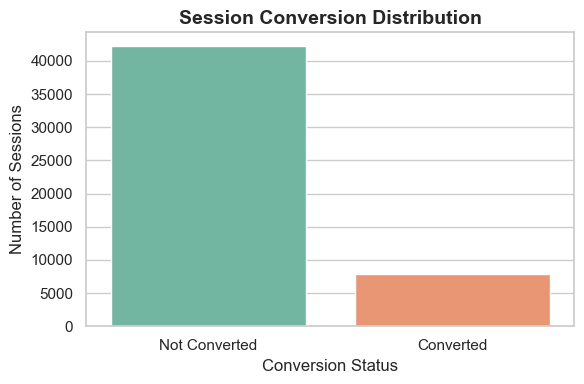

In [41]:
# =====================================================
# Session Conversion Distribution
# =====================================================

# Create a plotting canvas
plt.figure(figsize=(6, 4))

# Plot the number of converted and non-converted sessions
sns.countplot(
    data=sessions,
    x="converted",
    hue="converted",
    palette="Set2",
    legend=False
)

# Improve readability by replacing 0 and 1 with descriptive labels
plt.xticks([0, 1], ["Not Converted", "Converted"])

# Add chart title and axis labels
plt.title("Session Conversion Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Conversion Status")
plt.ylabel("Number of Sessions")

# Adjust layout
plt.tight_layout()

# Display the chart
plt.show()

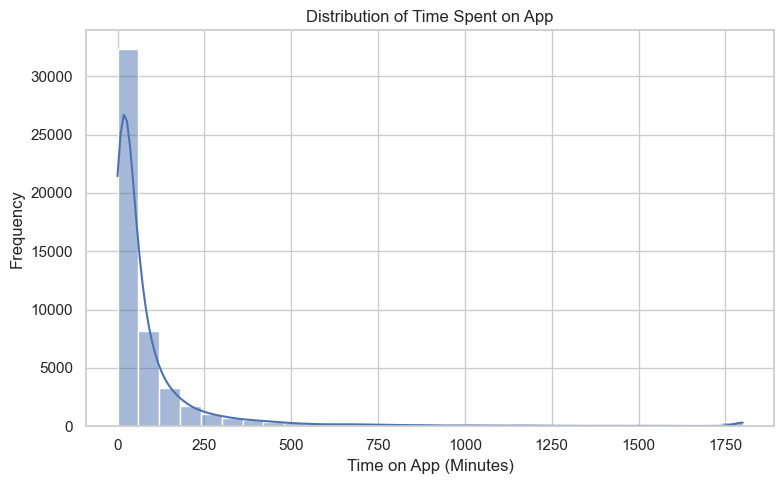

In [45]:
# =====================================================
# Distribution of Time Spent on App
# =====================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data=sessions,
    x="time_on_app",
    bins=30,
    kde=True
)

plt.title("Distribution of Time Spent on App")
plt.xlabel("Time on App (Minutes)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

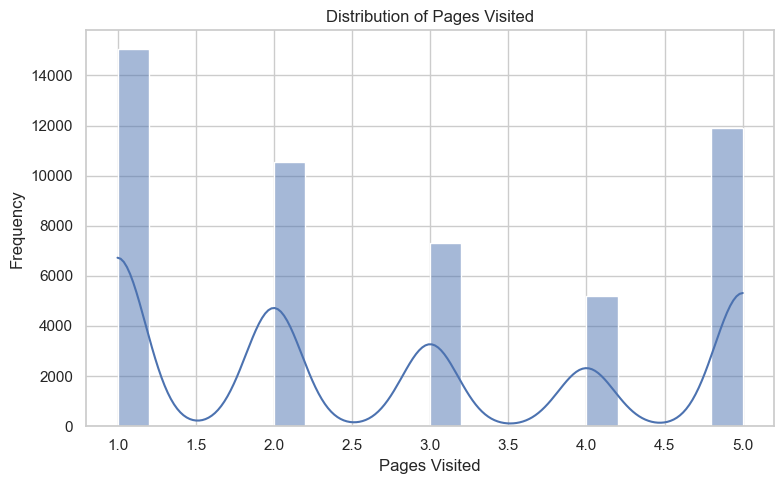

In [49]:
# =====================================================
# Distribution of Pages Visited
# =====================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data=sessions,
    x="pages_visited",
    bins=20,
    kde=True
)

plt.title("Distribution of Pages Visited")
plt.xlabel("Pages Visited")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

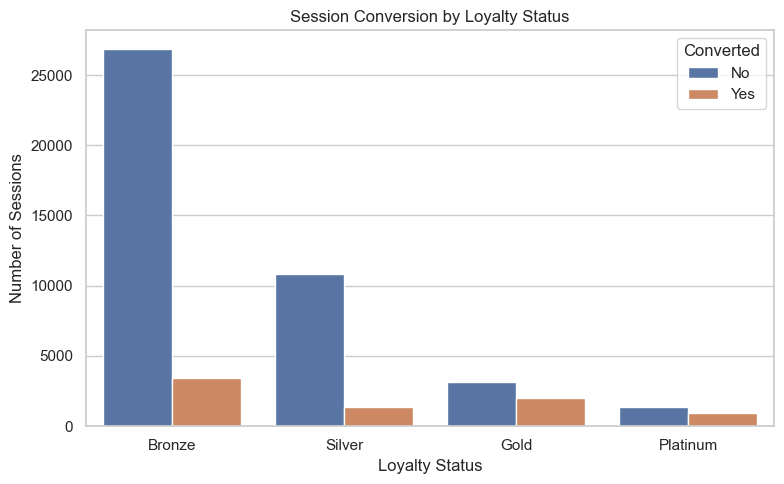

In [47]:
# =====================================================
# Session Conversion by Loyalty Status
# =====================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=sessions,
    x="loyalty_status",
    hue="converted"
)

plt.title("Session Conversion by Loyalty Status")
plt.xlabel("Loyalty Status")
plt.ylabel("Number of Sessions")
plt.legend(title="Converted", labels=["No", "Yes"])

plt.tight_layout()
plt.show()

EDA FOR Trips

In [48]:
trips.columns.tolist()

['trip_id',
 'user_id',
 'driver_id',
 'fare',
 'surge_multiplier',
 'tip',
 'payment_type',
 'pickup_time',
 'dropoff_time',
 'pickup_lat',
 'pickup_lng',
 'dropoff_lat',
 'dropoff_lng',
 'weather',
 'city',
 'loyalty_status']

In [51]:
print(trips.columns.tolist())

['trip_id', 'user_id', 'driver_id', 'fare', 'surge_multiplier', 'tip', 'payment_type', 'pickup_time', 'dropoff_time', 'pickup_lat', 'pickup_lng', 'dropoff_lat', 'dropoff_lng', 'weather', 'city', 'loyalty_status']


EDA FOR TABLE: trips

Categorical Feature Exploration

Column: trip_id
--------------------------------------------------
         Count  Percentage (%)
trip_id                       
T000000      1             0.0
T000001      1             0.0
T000002      1             0.0
T000003      1             0.0
T000004      1             0.0
...        ...             ...
T199995      1             0.0
T199996      1             0.0
T199997      1             0.0
T199998      1             0.0
T199999      1             0.0

[200000 rows x 2 columns]

Column: user_id
--------------------------------------------------
         Count  Percentage (%)
user_id                       
R08152      42            0.02
R06728      39            0.02
R09210      38            0.02
R09908      37            0.02
R00739      37            0.02
...        ...             ...
R01782       7            0.00
R06836       7            0.00
R00197       6            0.00
R01184       6            0.00
R03232  

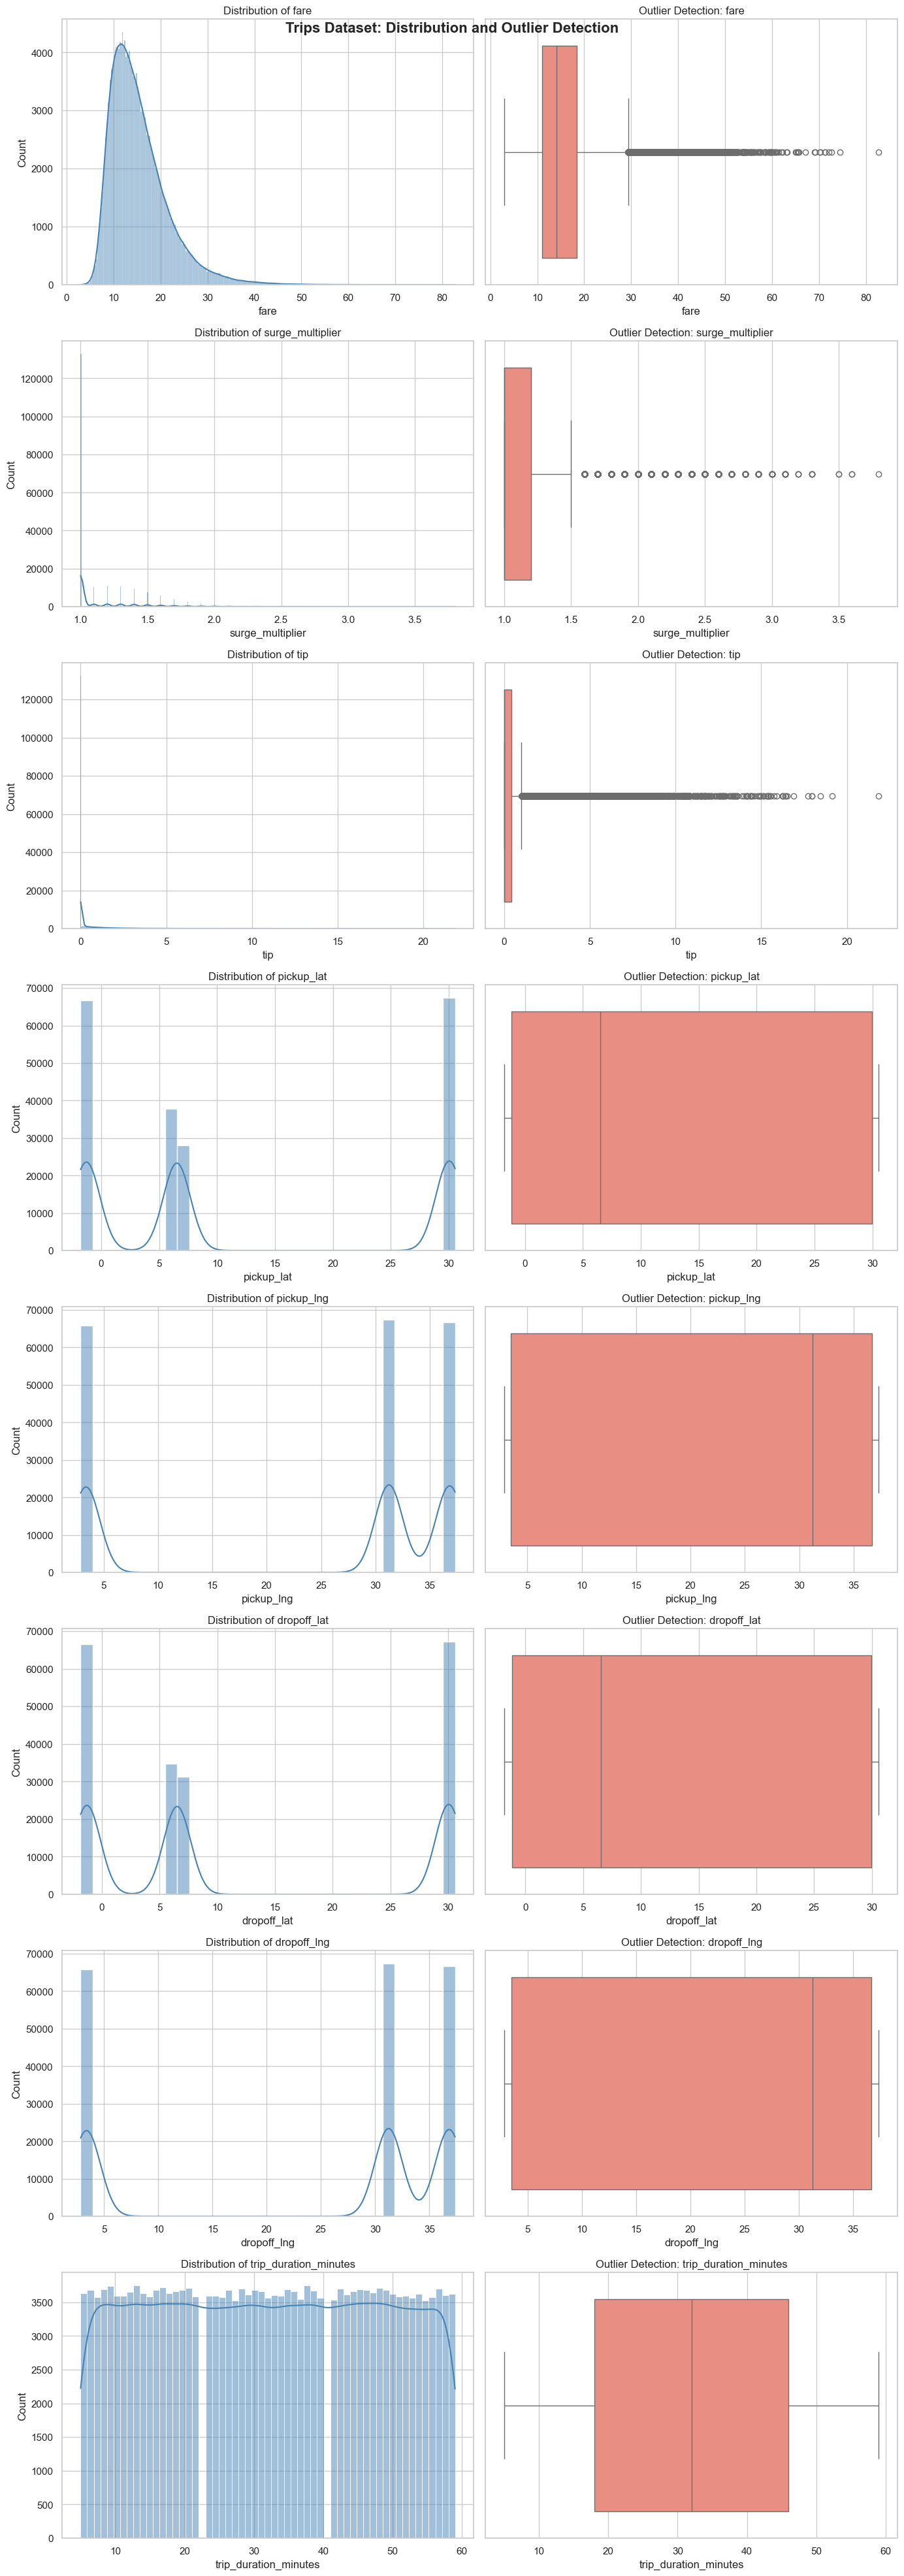

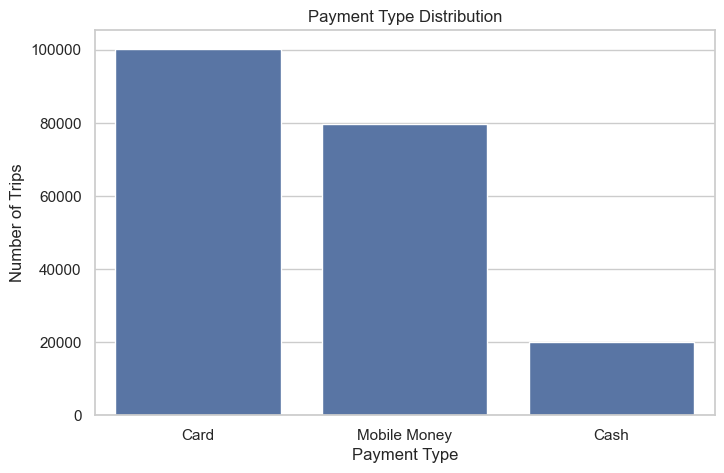

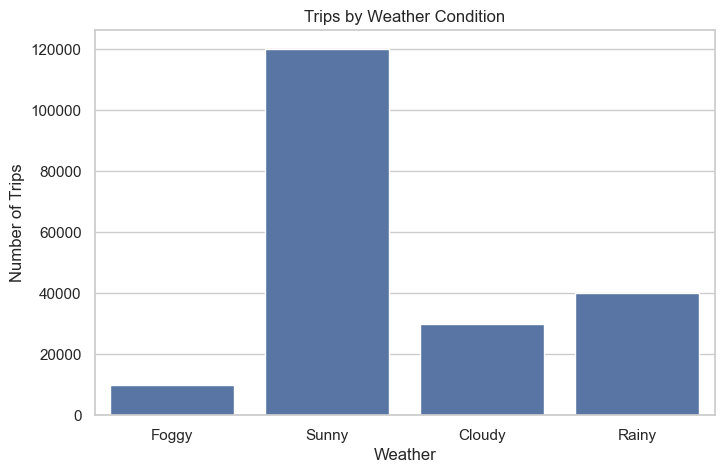

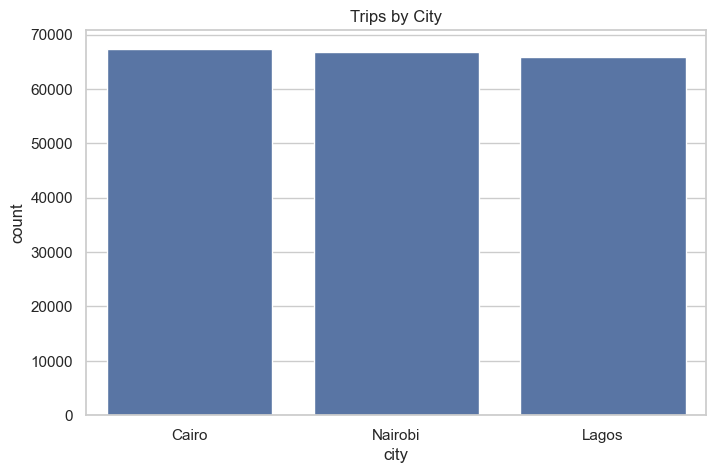

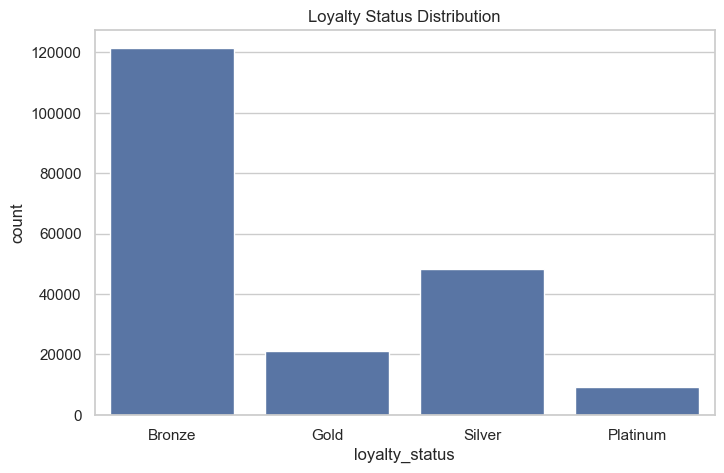

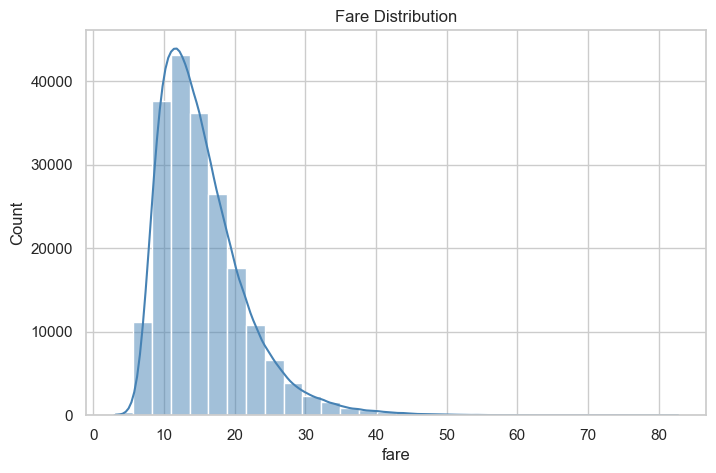

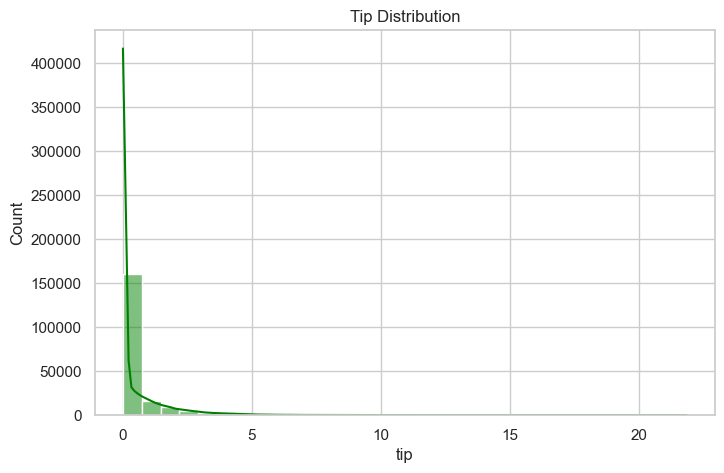

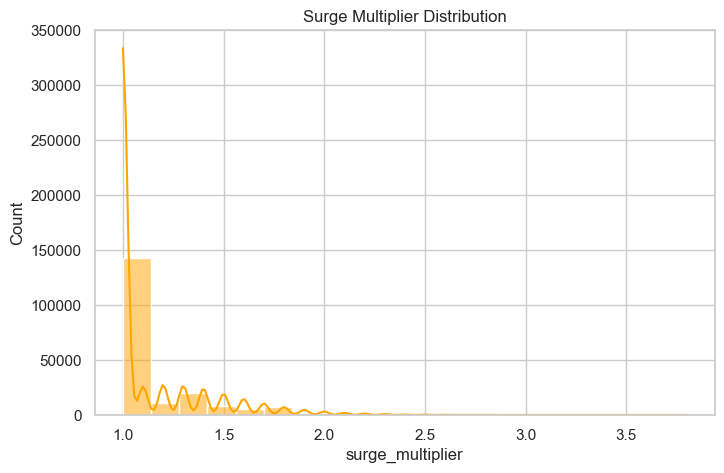

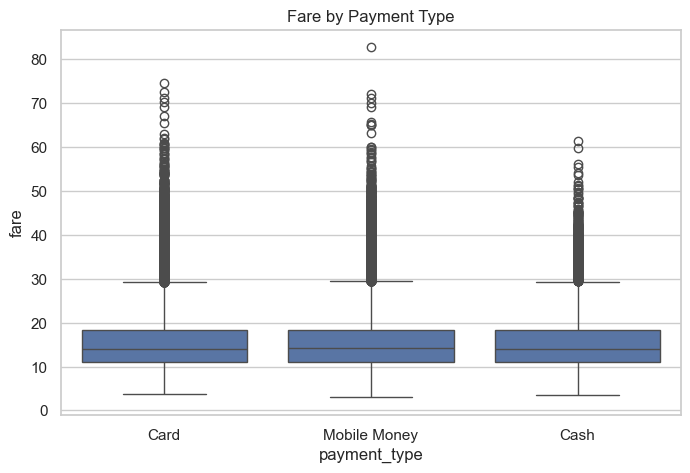

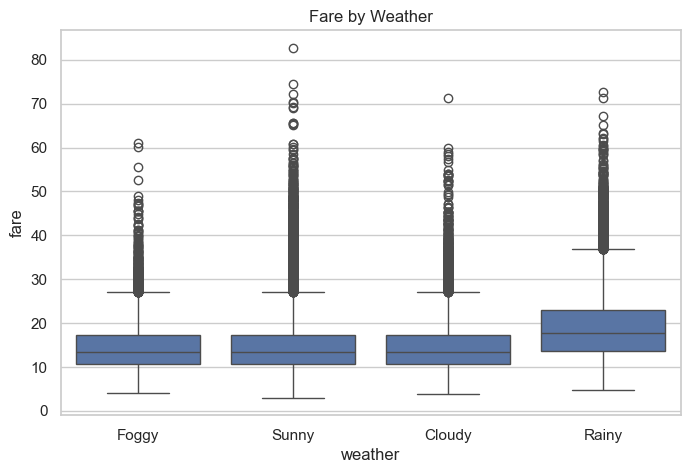

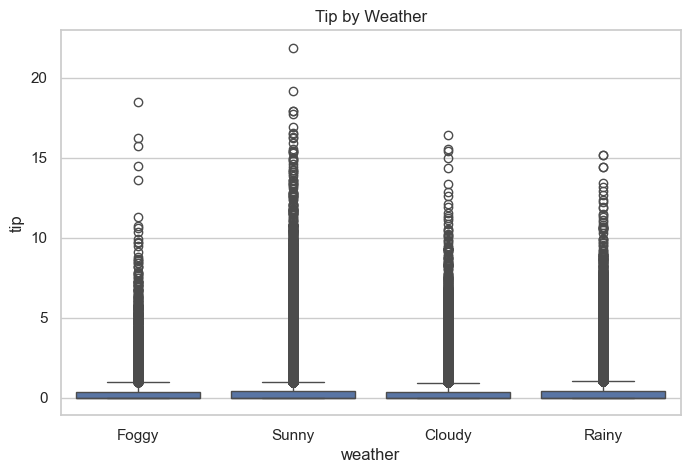

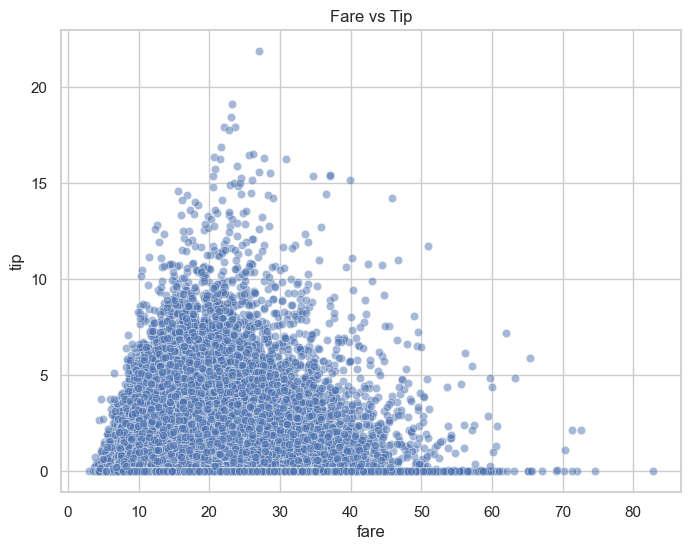

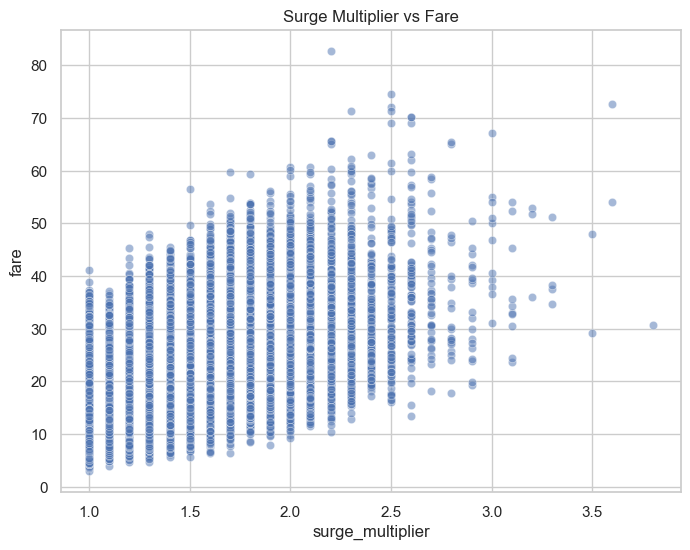

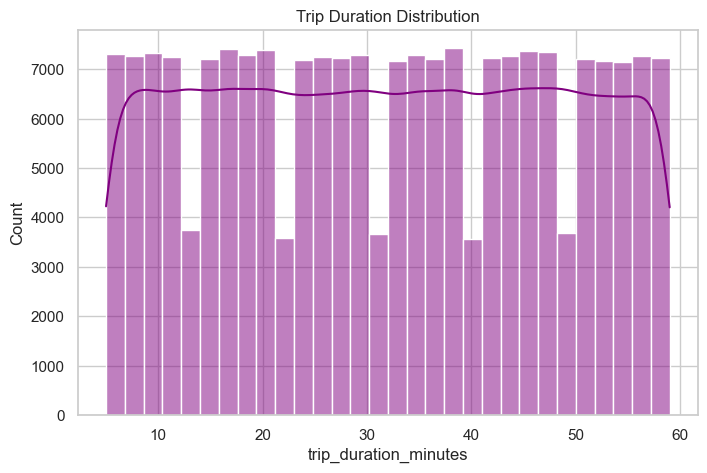

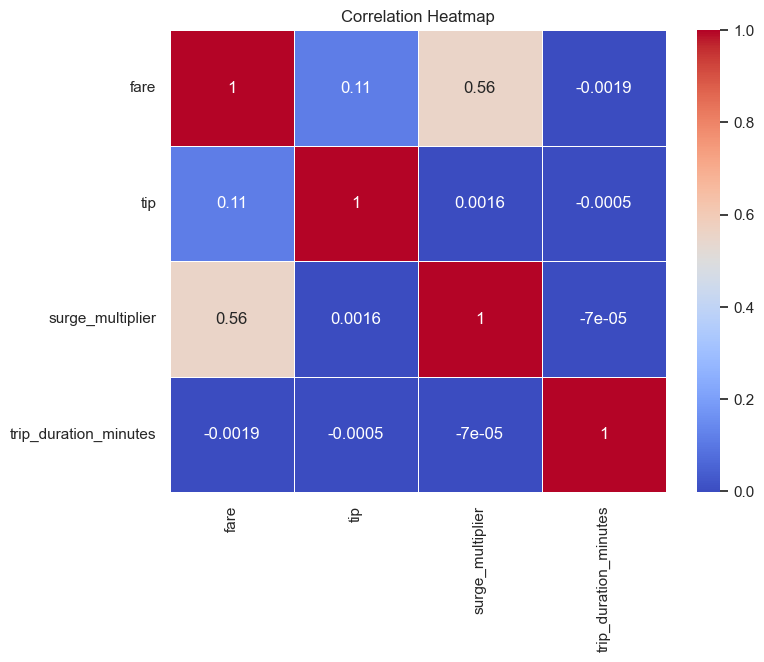

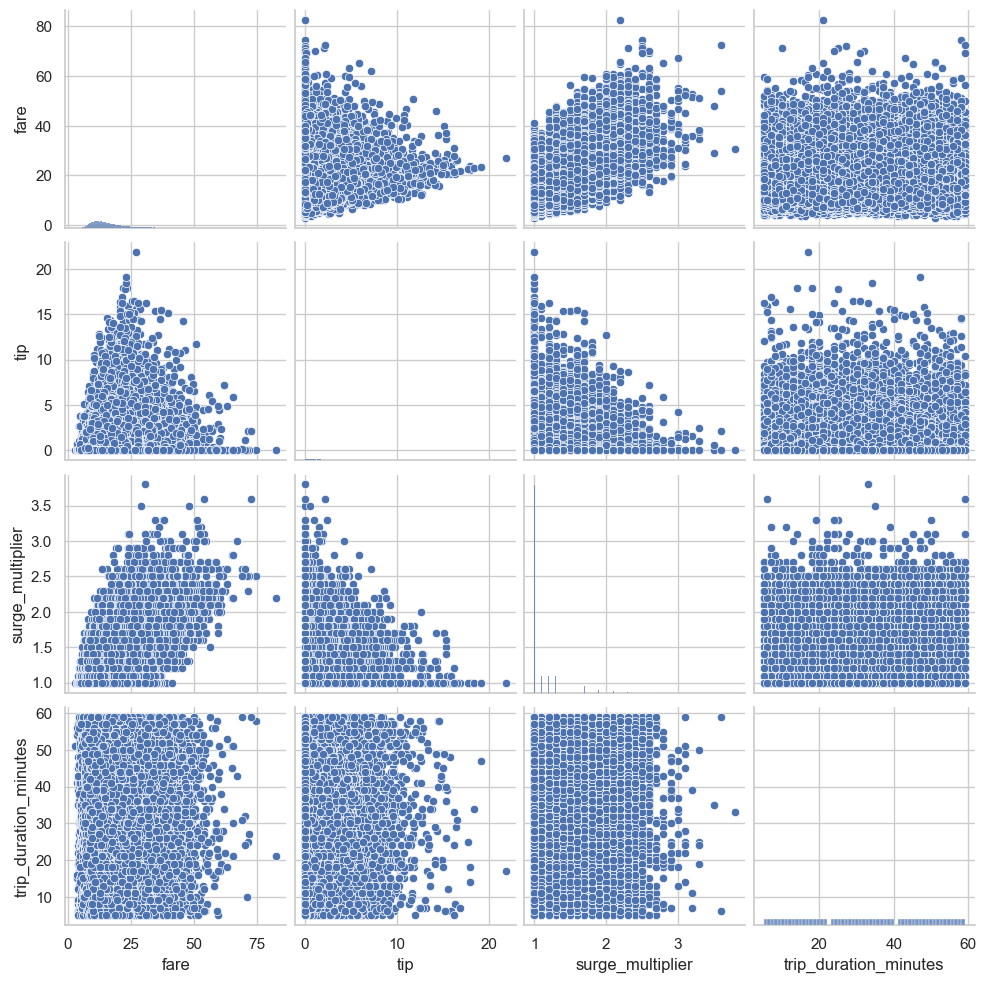

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set plotting style
sns.set_theme(style="whitegrid")

print("==================================================")
print("EDA FOR TABLE: trips")
print("==================================================")

# ==================================================
# Dataset Overview
# ==================================================

# ==================================================
# Explore Categorical Features
# ==================================================

print("\n==================================================")
print("Categorical Feature Exploration")
print("==================================================")

categorical_cols = trips.select_dtypes(include=["object", "string"]).columns

for col in categorical_cols:

    print(f"\nColumn: {col}")
    print("-" * 50)

    counts = trips[col].value_counts()

    percentages = round(
        trips[col].value_counts(normalize=True) * 100,
        2
    )

    summary = pd.DataFrame({
        "Count": counts,
        "Percentage (%)": percentages
    })

    print(summary)

# ==================================================
# Explore Numerical Features
# ==================================================

numerical_cols = trips.select_dtypes(include="number").columns

print("\nNumerical Features")
print(numerical_cols)

# ==================================================
# Distribution and Outlier Detection
# ==================================================

fig, axes = plt.subplots(
    len(numerical_cols),
    2,
    figsize=(14, 5 * len(numerical_cols))
)

fig.suptitle(
    "Trips Dataset: Distribution and Outlier Detection",
    fontsize=16,
    fontweight="bold"
)

for i, col in enumerate(numerical_cols):

    # Histogram showing feature distribution
    sns.histplot(
        data=trips,
        x=col,
        kde=True,
        color="steelblue",
        ax=axes[i, 0]
    )

    axes[i, 0].set_title(f"Distribution of {col}")

    # Boxplot highlighting potential outliers
    sns.boxplot(
        data=trips,
        x=col,
        color="salmon",
        ax=axes[i, 1]
    )

    axes[i, 1].set_title(f"Outlier Detection: {col}")

plt.tight_layout()
plt.show()

# ==================================================
# Payment Type Distribution
# Purpose:
# Show the frequency of each payment method.
# ==================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=trips,
    x="payment_type"
)

plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Trips")

plt.show()

# ==================================================
# Weather Distribution
# Purpose:
# Show weather conditions during trips.
# ==================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=trips,
    x="weather"
)

plt.title("Trips by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Number of Trips")

plt.show()

# ==================================================
# Trips by City
# Purpose:
# Display the number of trips completed in each city.
# ==================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=trips,
    x="city",
    order=trips["city"].value_counts().index
)

plt.title("Trips by City")

plt.show()

# ==================================================
# Loyalty Status Distribution
# Purpose:
# Display rider loyalty categories.
# ==================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=trips,
    x="loyalty_status"
)

plt.title("Loyalty Status Distribution")

plt.show()

# ==================================================
# Fare Distribution
# Purpose:
# Examine the distribution of trip fares.
# ==================================================

plt.figure(figsize=(8,5))

sns.histplot(
    trips["fare"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Fare Distribution")

plt.show()

# ==================================================
# Tip Distribution
# Purpose:
# Examine how much riders tip drivers.
# ==================================================

plt.figure(figsize=(8,5))

sns.histplot(
    trips["tip"],
    bins=30,
    kde=True,
    color="green"
)

plt.title("Tip Distribution")

plt.show()

# ==================================================
# Surge Multiplier Distribution
# Purpose:
# Understand surge pricing patterns.
# ==================================================

plt.figure(figsize=(8,5))

sns.histplot(
    trips["surge_multiplier"],
    bins=20,
    kde=True,
    color="orange"
)

plt.title("Surge Multiplier Distribution")

plt.show()

# ==================================================
# Fare by Payment Type
# Purpose:
# Compare fare distributions across payment methods.
# ==================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=trips,
    x="payment_type",
    y="fare"
)

plt.title("Fare by Payment Type")

plt.show()

# ==================================================
# Fare by Weather
# Purpose:
# Compare fares across different weather conditions.
# ==================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=trips,
    x="weather",
    y="fare"
)

plt.title("Fare by Weather")

plt.show()

# ==================================================
# Tip by Weather
# Purpose:
# Compare rider tipping behaviour across weather conditions.
# ==================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=trips,
    x="weather",
    y="tip"
)

plt.title("Tip by Weather")

plt.show()

# ==================================================
# Fare vs Tip
# Purpose:
# Explore the relationship between fare and tip amount.
# ==================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=trips,
    x="fare",
    y="tip",
    alpha=0.5
)

plt.title("Fare vs Tip")

plt.show()

# ==================================================
# Surge Multiplier vs Fare
# Purpose:
# Determine whether higher surge multipliers
# result in higher fares.
# ==================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=trips,
    x="surge_multiplier",
    y="fare",
    alpha=0.5
)

plt.title("Surge Multiplier vs Fare")

plt.show()

# ==================================================
# Calculate Trip Duration
# Purpose:
# Create a new feature representing the duration
# of each trip in minutes.
# ==================================================

trips["pickup_time"] = pd.to_datetime(trips["pickup_time"])
trips["dropoff_time"] = pd.to_datetime(trips["dropoff_time"])

trips["trip_duration_minutes"] = (
    trips["dropoff_time"] - trips["pickup_time"]
).dt.total_seconds() / 60

# ==================================================
# Trip Duration Distribution
# ==================================================

plt.figure(figsize=(8,5))

sns.histplot(
    trips["trip_duration_minutes"],
    bins=30,
    kde=True,
    color="purple"
)

plt.title("Trip Duration Distribution")

plt.show()

# ==================================================
# Correlation Heatmap
# Purpose:
# Show relationships between numerical variables.
# ==================================================

numeric_cols = [
    "fare",
    "tip",
    "surge_multiplier",
    "trip_duration_minutes"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    trips[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

# ==================================================
# Pair Plot
# Purpose:
# Explore pairwise relationships between numerical variables.
# ==================================================

sns.pairplot(
    trips[numeric_cols]
)

plt.show()

In [59]:
# Display all column names
promotions.columns.tolist()

['promo_id',
 'promo_name',
 'promo_type',
 'promo_value',
 'start_date',
 'end_date',
 'target_segment',
 'city_scope',
 'ab_test_groups',
 'test_allocation',
 'success_metric']

In [61]:
print("==================================================")
print("EDA FOR TABLE: promotions")
print("==================================================")

print("\n--- Categorical & Strategic Campaign Exploration ---")

categorical_cols = [
    "promo_name",
    "promo_type",
    "target_segment",
    "city_scope",
    "ab_test_groups",
    "success_metric"
]

for col in categorical_cols:

    print(f"\nFeature: '{col}'")
    print("-" * 60)

    cardinality = promotions[col].nunique()

    print(f"Distinct Categories (Cardinality): {cardinality}")

    summary = pd.DataFrame({
        "Count": promotions[col].value_counts(),
        "Percentage (%)": round(
            promotions[col].value_counts(normalize=True) * 100,
            2
        )
    })

    print(summary)

EDA FOR TABLE: promotions

--- Categorical & Strategic Campaign Exploration ---

Feature: 'promo_name'
------------------------------------------------------------
Distinct Categories (Cardinality): 4
                     Count  Percentage (%)
promo_name                                
First Ride Discount      8            40.0
Peak Hour Pass           5            25.0
Loyalty Bonus            5            25.0
Referral Special         2            10.0

Feature: 'promo_type'
------------------------------------------------------------
Distinct Categories (Cardinality): 4
              Count  Percentage (%)
promo_type                         
discount          8            40.0
surge_waiver      5            25.0
points            5            25.0
credit            2            10.0

Feature: 'target_segment'
------------------------------------------------------------
Distinct Categories (Cardinality): 4
                Count  Percentage (%)
target_segment                       
New

C:\Users\User.DESKTOP-775\AppData\Local\Temp\ipykernel_45444\1695158372.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


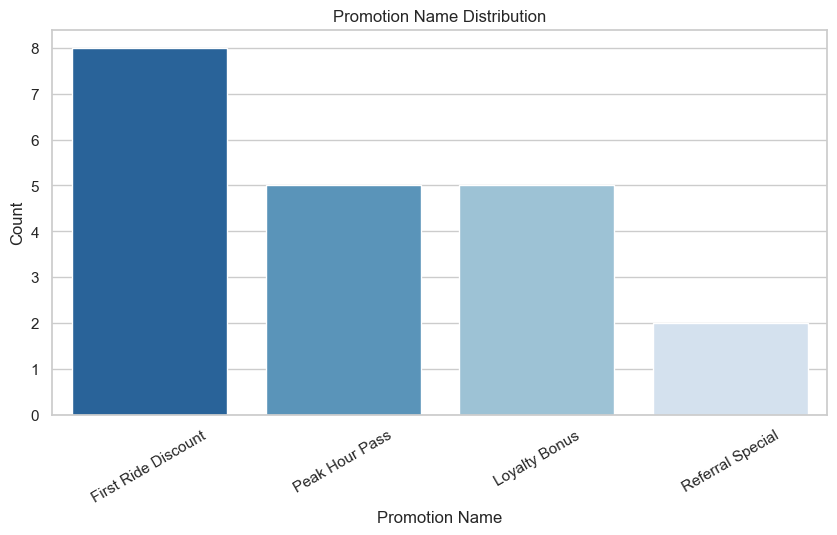

C:\Users\User.DESKTOP-775\AppData\Local\Temp\ipykernel_45444\1695158372.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


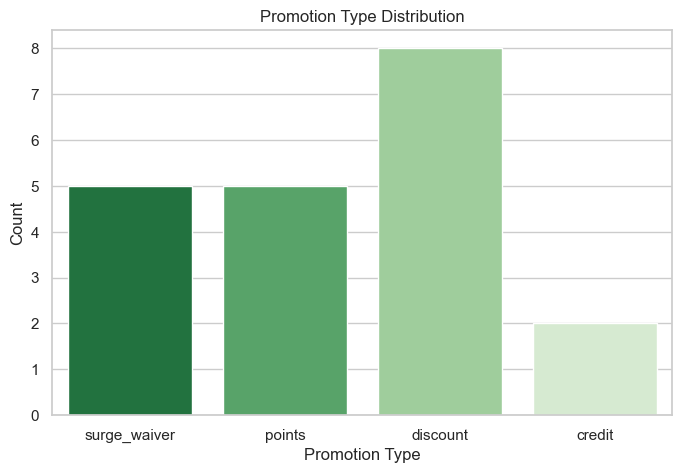

C:\Users\User.DESKTOP-775\AppData\Local\Temp\ipykernel_45444\1695158372.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


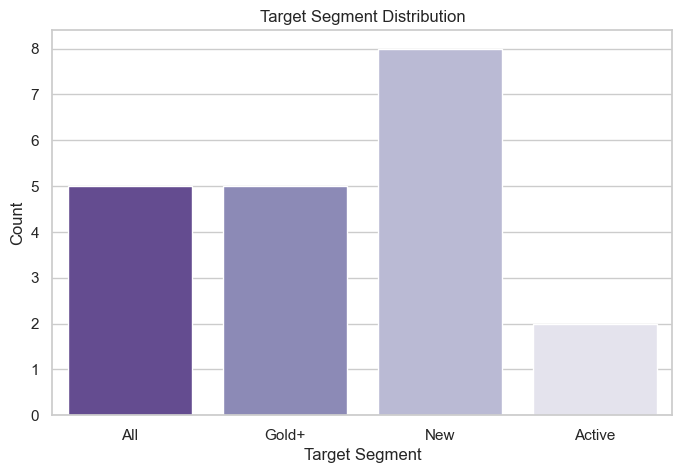

C:\Users\User.DESKTOP-775\AppData\Local\Temp\ipykernel_45444\1695158372.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


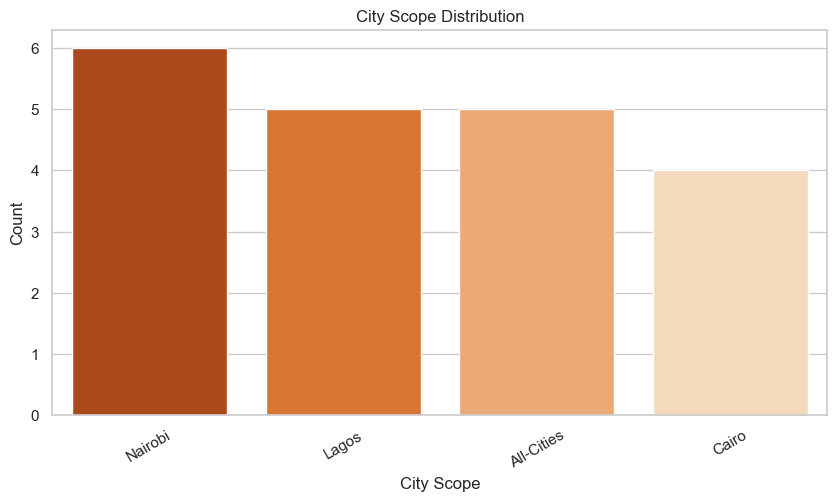

C:\Users\User.DESKTOP-775\AppData\Local\Temp\ipykernel_45444\1695158372.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


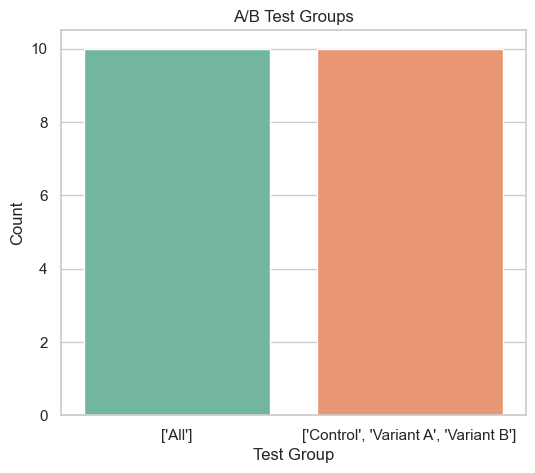

C:\Users\User.DESKTOP-775\AppData\Local\Temp\ipykernel_45444\1695158372.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


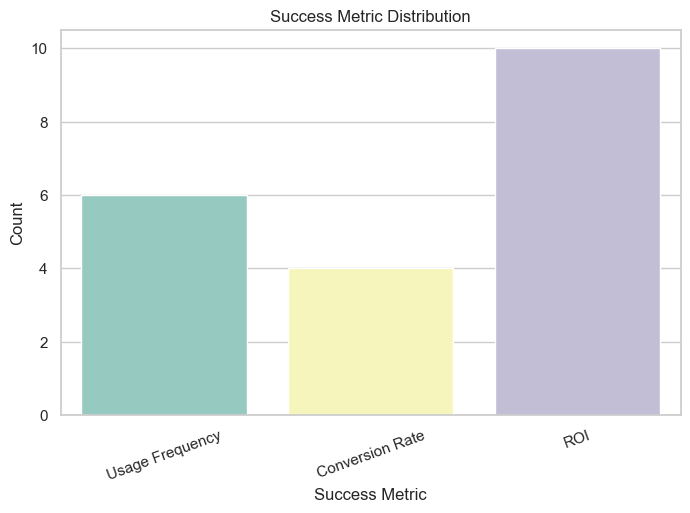

In [63]:
# ==================================================
# Promotion Name Distribution
# ==================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=promotions,
    x="promo_name",
    order=promotions["promo_name"].value_counts().index,
    palette="Blues_r"
)

plt.title("Promotion Name Distribution")
plt.xlabel("Promotion Name")
plt.ylabel("Count")

plt.xticks(rotation=30)

plt.show()

# ==================================================
# Promotion Type Distribution
# ==================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=promotions,
    x="promo_type",
    palette="Greens_r"
)

plt.title("Promotion Type Distribution")
plt.xlabel("Promotion Type")
plt.ylabel("Count")

plt.show()

# ==================================================
# Target Segment Distribution
# ==================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=promotions,
    x="target_segment",
    palette="Purples_r"
)

plt.title("Target Segment Distribution")
plt.xlabel("Target Segment")
plt.ylabel("Count")

plt.show()

# ==================================================
# City Scope Distribution
# ==================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=promotions,
    x="city_scope",
    order=promotions["city_scope"].value_counts().index,
    palette="Oranges_r"
)

plt.title("City Scope Distribution")
plt.xlabel("City Scope")
plt.ylabel("Count")

plt.xticks(rotation=30)

plt.show()

# ==================================================
# A/B Test Groups Distribution
# ==================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=promotions,
    x="ab_test_groups",
    palette="Set2"
)

plt.title("A/B Test Groups")
plt.xlabel("Test Group")
plt.ylabel("Count")

plt.show()

# ==================================================
# Success Metric Distribution
# ==================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=promotions,
    x="success_metric",
    palette="Set3"
)

plt.title("Success Metric Distribution")
plt.xlabel("Success Metric")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.show()

VISUAL EXPLORATION FOR TABLE: promotions


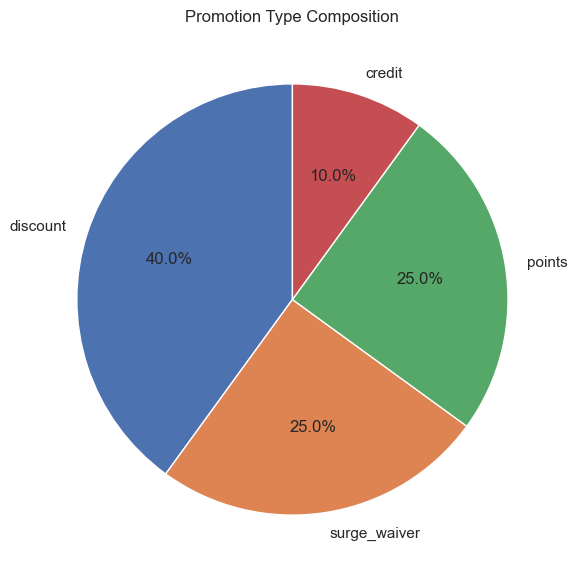

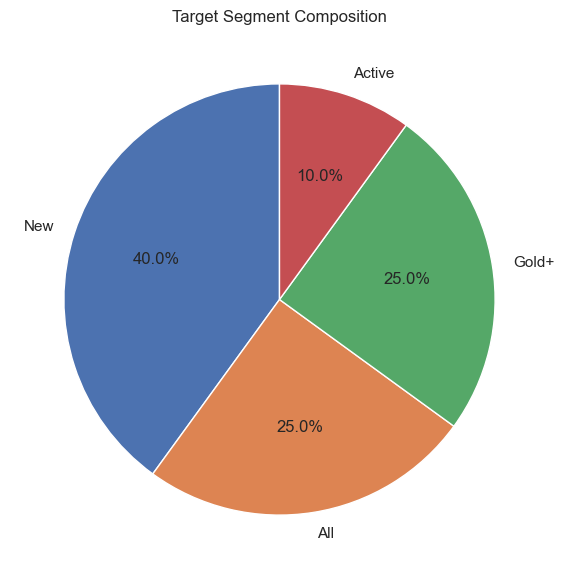

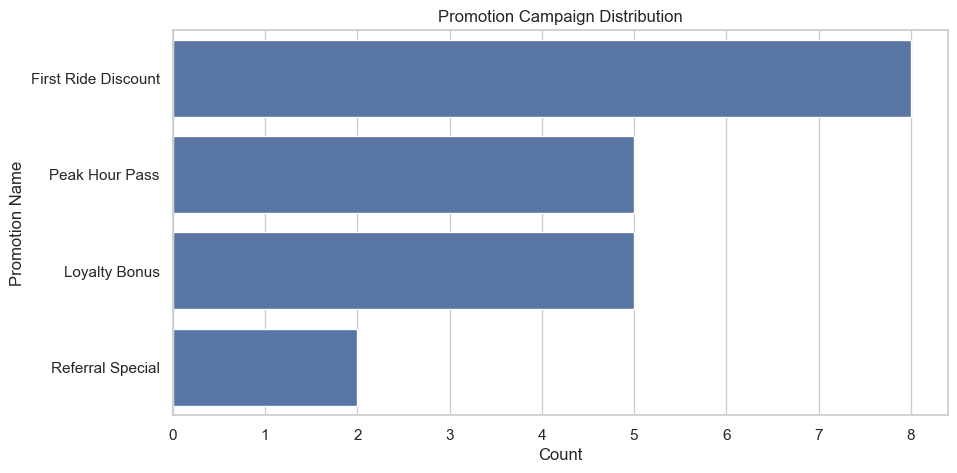

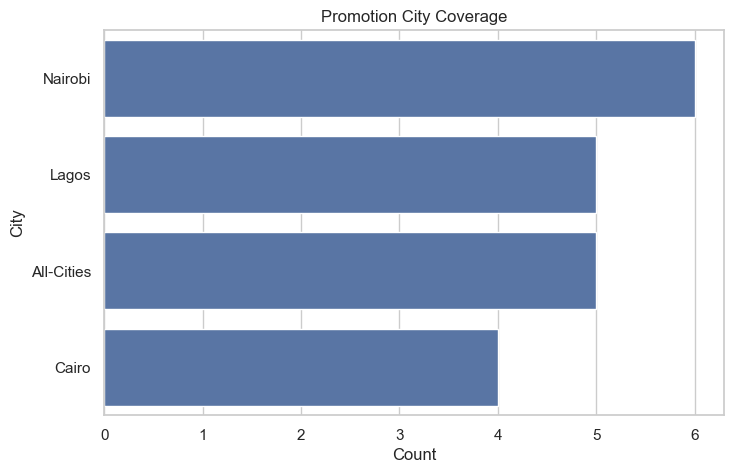

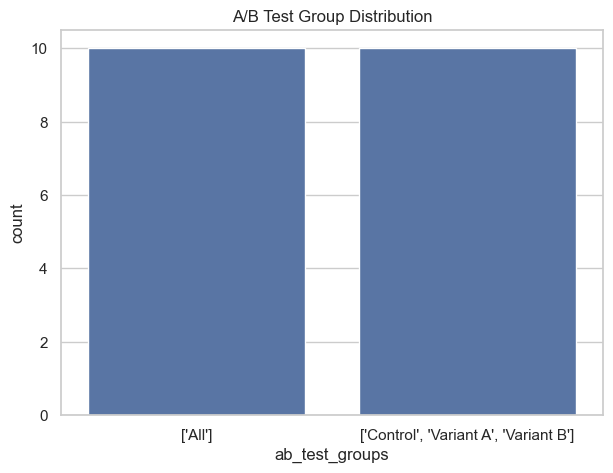

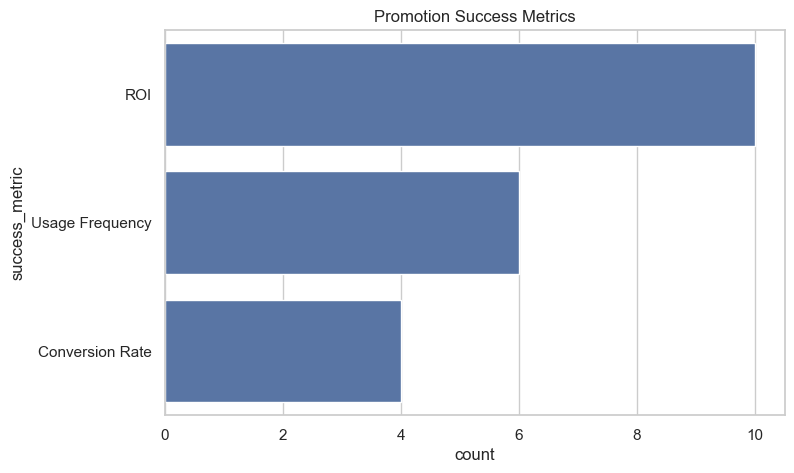

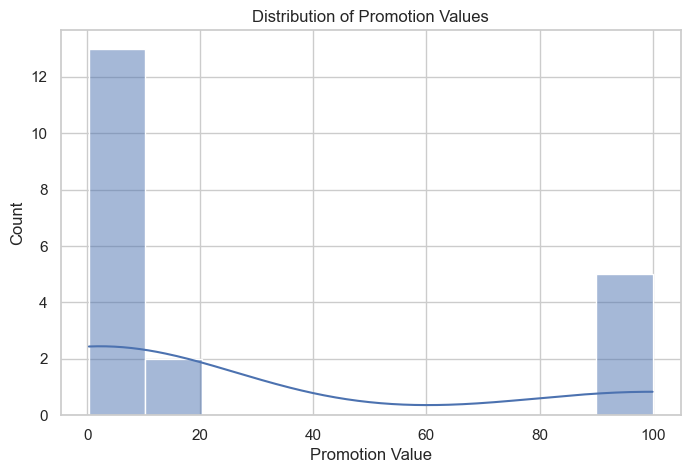

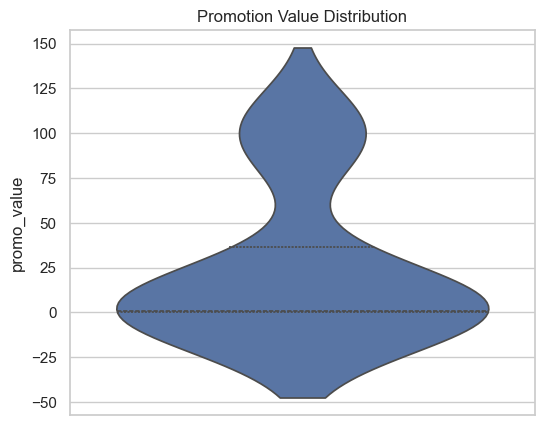

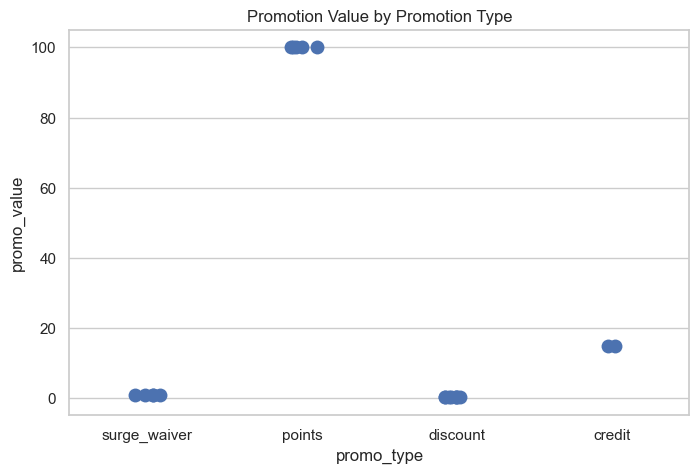

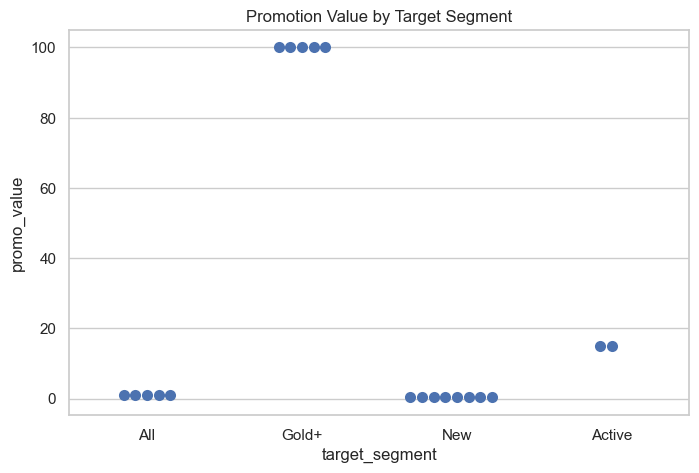

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

print("==================================================")
print("VISUAL EXPLORATION FOR TABLE: promotions")
print("==================================================")

# ==================================================
# Promotion Type Composition
# Purpose:
# Show the proportion of each promotion type.
# ==================================================

plt.figure(figsize=(7,7))

promotions["promo_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Promotion Type Composition")
plt.ylabel("")

plt.show()

# ==================================================
# Target Segment Composition
# Purpose:
# Show the proportion of customer segments.
# ==================================================

plt.figure(figsize=(7,7))

promotions["target_segment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Target Segment Composition")
plt.ylabel("")

plt.show()

# ==================================================
# Promotion Name Distribution
# Purpose:
# Display the frequency of each promotion campaign.
# ==================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=promotions,
    y="promo_name",
    order=promotions["promo_name"].value_counts().index
)

plt.title("Promotion Campaign Distribution")
plt.xlabel("Count")
plt.ylabel("Promotion Name")

plt.show()

# ==================================================
# City Scope Distribution
# Purpose:
# Show where promotions are available.
# ==================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=promotions,
    y="city_scope",
    order=promotions["city_scope"].value_counts().index
)

plt.title("Promotion City Coverage")
plt.xlabel("Count")
plt.ylabel("City")

plt.show()

# ==================================================
# A/B Test Group Distribution
# Purpose:
# Display the number of campaigns in each
# experimental group.
# ==================================================

plt.figure(figsize=(7,5))

sns.countplot(
    data=promotions,
    x="ab_test_groups"
)

plt.title("A/B Test Group Distribution")

plt.show()

# ==================================================
# Success Metric Distribution
# Purpose:
# Show the business metric used to evaluate
# each campaign.
# ==================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=promotions,
    y="success_metric",
    order=promotions["success_metric"].value_counts().index
)

plt.title("Promotion Success Metrics")

plt.show()

# ==================================================
# Promotion Value Distribution
# Purpose:
# Examine the distribution of promotion values.
# ==================================================

plt.figure(figsize=(8,5))

sns.histplot(
    promotions["promo_value"],
    bins=10,
    kde=True
)

plt.title("Distribution of Promotion Values")
plt.xlabel("Promotion Value")

plt.show()

# ==================================================
# Promotion Value Distribution
# Purpose:
# Display the density and spread of promotion values.
# ==================================================

plt.figure(figsize=(6,5))

sns.violinplot(
    y=promotions["promo_value"],
    inner="quartile"
)

plt.title("Promotion Value Distribution")

plt.show()

# ==================================================
# Promotion Value by Promotion Type
# Purpose:
# Compare promotion values across promotion types.
# ==================================================

plt.figure(figsize=(8,5))

sns.stripplot(
    data=promotions,
    x="promo_type",
    y="promo_value",
    jitter=True,
    size=10
)

plt.title("Promotion Value by Promotion Type")

plt.show()

# ==================================================
# Promotion Value by Target Segment
# Purpose:
# Compare promotion values across customer segments.
# ==================================================

plt.figure(figsize=(8,5))

sns.swarmplot(
    data=promotions,
    x="target_segment",
    y="promo_value",
    size=8
)

plt.title("Promotion Value by Target Segment")

plt.show()

# ==================================================
# Promotion Duration Distribution
# Purpose:
# Examine the duration of promotion campaigns.
# Assumes 'promotion_duration_days' exists.
# ==================================================

if "promotion_duration_days" in promotions.columns:

    plt.figure(figsize=(8,5))

    sns.histplot(
        promotions["promotion_duration_days"],
        bins=10,
        kde=True
    )

    plt.title("Promotion Duration Distribution")
    plt.xlabel("Duration (Days)")

    plt.show()

# ==================================================
# Promotion Duration vs Promotion Value
# Purpose:
# Explore whether longer campaigns offer
# higher promotion values.
# ==================================================

if "promotion_duration_days" in promotions.columns:

    plt.figure(figsize=(8,5))

    sns.scatterplot(
        data=promotions,
        x="promotion_duration_days",
        y="promo_value",
        s=120
    )

    plt.title("Promotion Duration vs Promotion Value")

    plt.show()

# ==================================================
# Correlation Heatmap
# Purpose:
# Show correlations between numerical variables.
# ==================================================

numeric_cols = promotions.select_dtypes(include="number").columns

if len(numeric_cols) > 1:

    plt.figure(figsize=(6,5))

    sns.heatmap(
        promotions[numeric_cols].corr(),
        annot=True,
        cmap="coolwarm",
        linewidths=0.5
    )

    plt.title("Correlation Heatmap")

    plt.show()

# ==================================================
# Pair Plot
# Purpose:
# Explore relationships between numerical variables.
# ==================================================

if len(numeric_cols) > 1:

    sns.pairplot(
        promotions[numeric_cols]
    )

    plt.show()

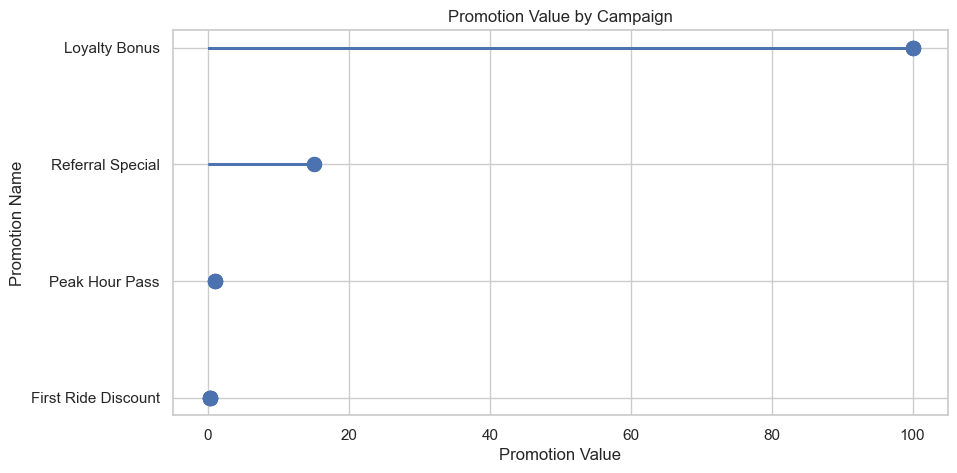

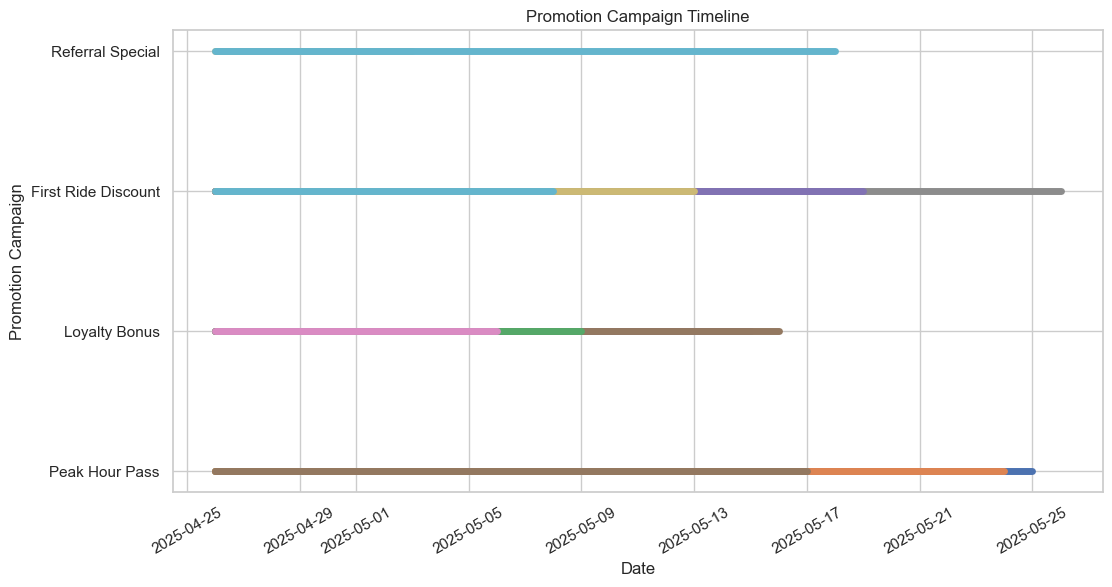

In [71]:
# ==================================================
# Promotion Value by Campaign (Lollipop Chart)
# Purpose:
# Compare the value offered by each promotion.
# ==================================================

plt.figure(figsize=(10,5))

# Sort promotions by promotion value
promo_sorted = promotions.sort_values("promo_value")

# Draw horizontal lines
plt.hlines(
    y=promo_sorted["promo_name"],
    xmin=0,
    xmax=promo_sorted["promo_value"],
    linewidth=2
)

# Draw the points
plt.plot(
    promo_sorted["promo_value"],
    promo_sorted["promo_name"],
    "o",
    markersize=10
)

plt.title("Promotion Value by Campaign")

plt.xlabel("Promotion Value")
plt.ylabel("Promotion Name")

plt.show()


# ==================================================
# Promotion Duration by Campaign (Dot Plot)
# Purpose:
# Compare the duration of each promotion campaign.
# Assumes 'promotion_duration_days' exists.
# ==================================================

if "promotion_duration_days" in promotions.columns:

    plt.figure(figsize=(10,5))

    plt.scatter(
        promotions["promotion_duration_days"],
        promotions["promo_name"],
        s=120
    )

    plt.title("Promotion Duration by Campaign")

    plt.xlabel("Duration (Days)")
    plt.ylabel("Promotion Name")

    plt.show()


# ==================================================
# Promotion Campaign Timeline
# Purpose:
# Visualise when each promotion starts and ends.
# Assumes start_date and end_date are datetime.
# ==================================================

plt.figure(figsize=(12,6))

for _, row in promotions.iterrows():

    plt.plot(
        [row["start_date"], row["end_date"]],
        [row["promo_name"], row["promo_name"]],
        linewidth=5
    )

plt.title("Promotion Campaign Timeline")

plt.xlabel("Date")
plt.ylabel("Promotion Campaign")

plt.xticks(rotation=30)

plt.show()


# ==================================================
# Bubble Chart
# Purpose:
# Explore the relationship between promotion duration
# and promotion value.
# Bubble size represents promotion value.
# Assumes 'promotion_duration_days' exists.
# ==================================================

if "promotion_duration_days" in promotions.columns:

    plt.figure(figsize=(8,6))

    plt.scatter(
        promotions["promotion_duration_days"],
        promotions["promo_value"],
        s=promotions["promo_value"] * 10,
        alpha=0.6
    )

    plt.title("Promotion Duration vs Promotion Value")

    plt.xlabel("Promotion Duration (Days)")
    plt.ylabel("Promotion Value")

    plt.show()

EDA For drivers

EDA FOR TABLE: drivers

Categorical Feature Exploration

Feature: 'vehicle_type'
------------------------------------------------------------
              Count  Percentage (%)
vehicle_type                       
Sedan          2439           48.78
SUV            1742           34.84
Motorcycle      675           13.50
Luxury          144            2.88

Feature: 'city'
------------------------------------------------------------
         Count  Percentage (%)
city                          
Lagos     1720           34.40
Nairobi   1709           34.18
Cairo     1571           31.42

Numerical Feature Exploration


,rating,acceptance_rate
count,5000.000000,5000.000000
mean,4.172440,0.695318
std,0.594073,0.186216
min,3.100000,0.100000
25%,3.700000,0.565169
50%,4.200000,0.697731
75%,4.700000,0.837700
max,5.000000,0.990000


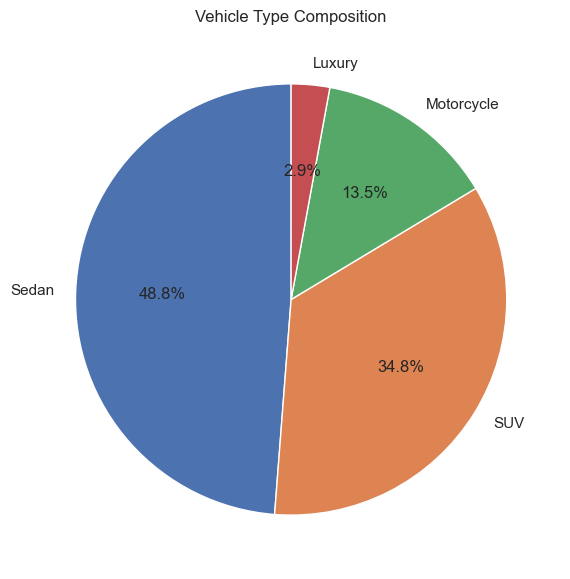

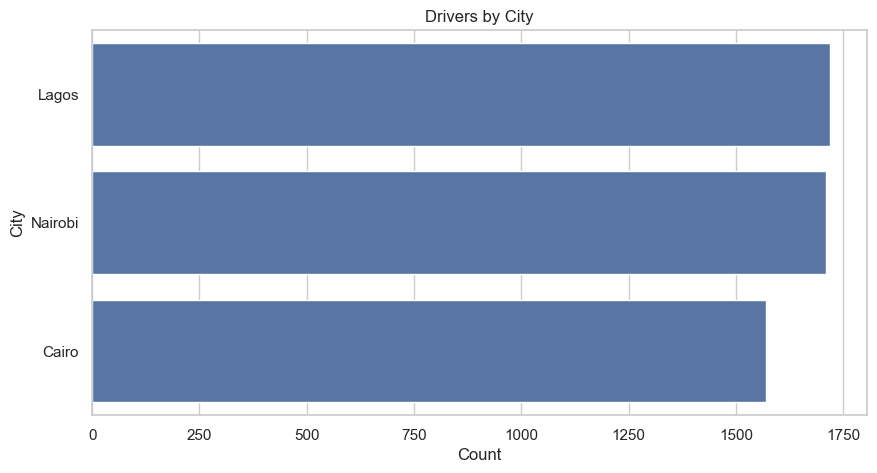

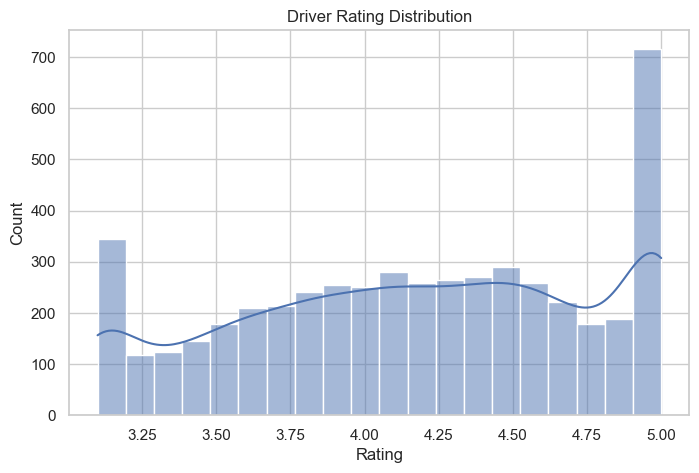

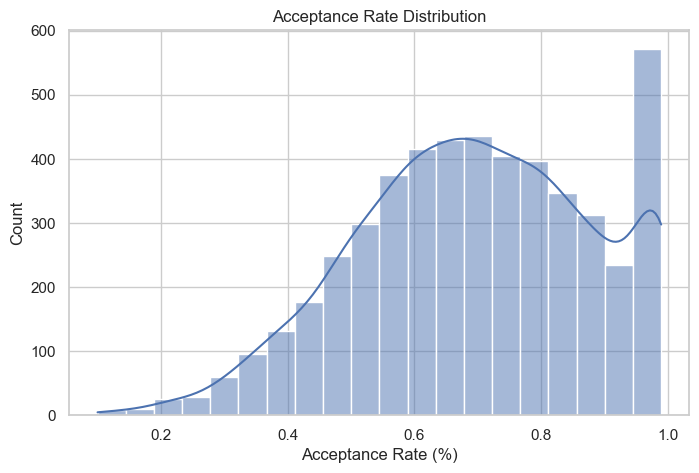

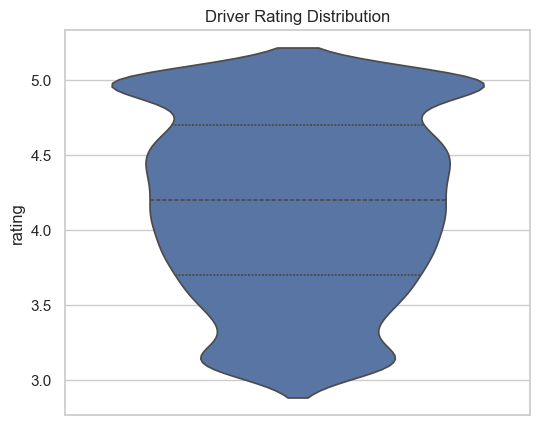

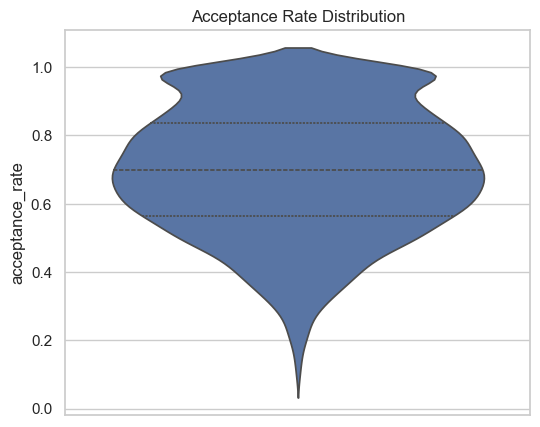

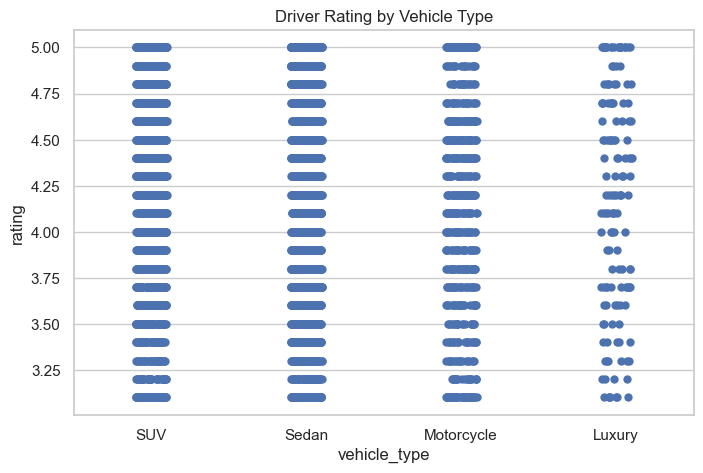

c:\Users\User.DESKTOP-775\ml_projects\fraud-detection-ml-platform\venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 52.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\User.DESKTOP-775\ml_projects\fraud-detection-ml-platform\venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 64.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\User.DESKTOP-775\ml_projects\fraud-detection-ml-platform\venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 13.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\User.DESKTOP-775\ml_projects\fraud-detection-ml-platform\venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 59.6% of the points cannot be placed; you may want to decre

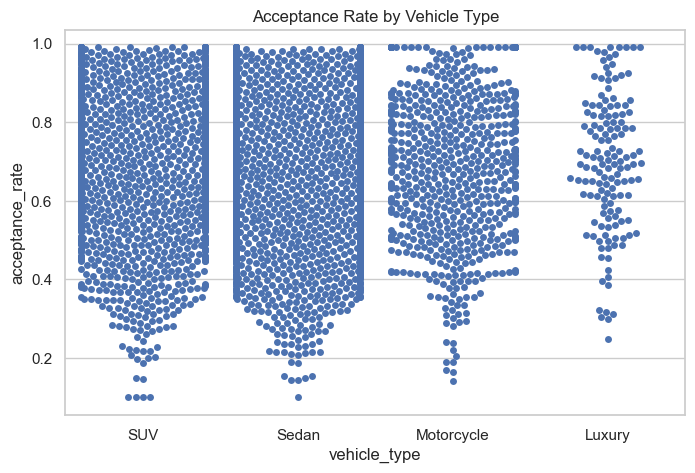

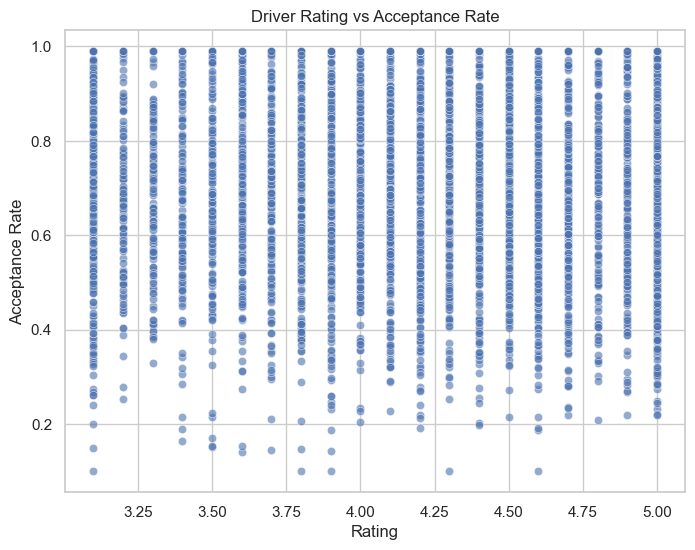

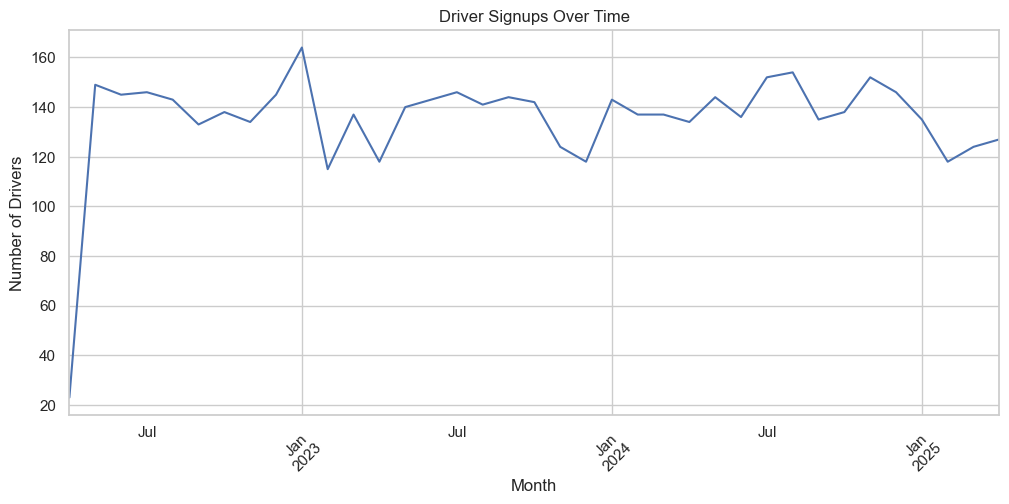

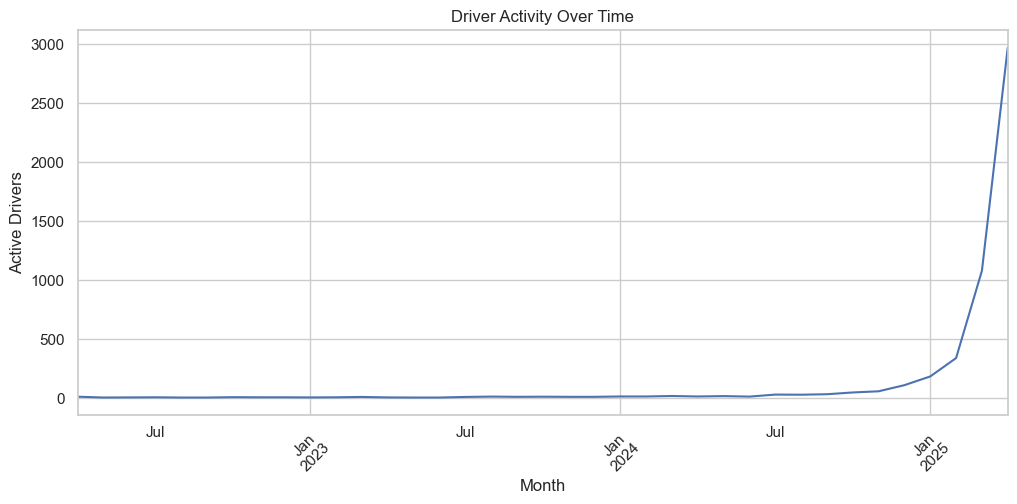

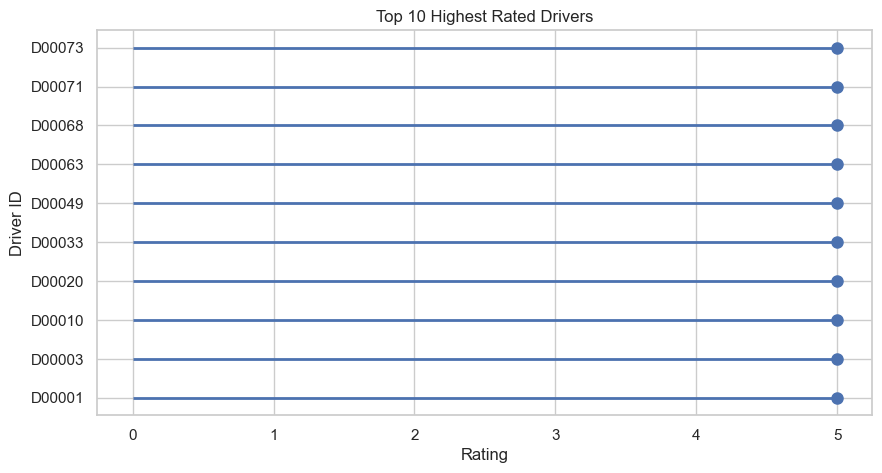

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

print("==================================================")
print("EDA FOR TABLE: drivers")
print("==================================================")


# ==================================================
# Categorical Feature Exploration
# ==================================================

print("\n==================================================")
print("Categorical Feature Exploration")
print("==================================================")

categorical_cols = [
    "vehicle_type",
    "city"
]

for col in categorical_cols:

    print(f"\nFeature: '{col}'")
    print("-"*60)

    print(
        pd.DataFrame({
            "Count": drivers[col].value_counts(),
            "Percentage (%)":
            round(drivers[col].value_counts(normalize=True)*100,2)
        })
    )

# ==================================================
# Numerical Feature Exploration
# ==================================================

print("\n==================================================")
print("Numerical Feature Exploration")
print("==================================================")

display(
    drivers[
        ["rating","acceptance_rate"]
    ].describe()
)

# ==================================================
# Vehicle Type Composition
# ==================================================

plt.figure(figsize=(7,7))

drivers["vehicle_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Vehicle Type Composition")

plt.ylabel("")

plt.show()

# ==================================================
# Drivers by City
# ==================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=drivers,
    y="city",
    order=drivers["city"].value_counts().index
)

plt.title("Drivers by City")

plt.xlabel("Count")

plt.ylabel("City")

plt.show()

# ==================================================
# Driver Rating Distribution
# ==================================================

plt.figure(figsize=(8,5))

sns.histplot(
    drivers["rating"],
    bins=20,
    kde=True
)

plt.title("Driver Rating Distribution")

plt.xlabel("Rating")

plt.show()

# ==================================================
# Acceptance Rate Distribution
# ==================================================

plt.figure(figsize=(8,5))

sns.histplot(
    drivers["acceptance_rate"],
    bins=20,
    kde=True
)

plt.title("Acceptance Rate Distribution")

plt.xlabel("Acceptance Rate (%)")

plt.show()

# ==================================================
# Driver Rating Distribution
# ==================================================

plt.figure(figsize=(6,5))

sns.violinplot(
    y=drivers["rating"],
    inner="quartile"
)

plt.title("Driver Rating Distribution")

plt.show()

# ==================================================
# Acceptance Rate Distribution
# ==================================================

plt.figure(figsize=(6,5))

sns.violinplot(
    y=drivers["acceptance_rate"],
    inner="quartile"
)

plt.title("Acceptance Rate Distribution")

plt.show()

# ==================================================
# Rating by Vehicle Type
# ==================================================

plt.figure(figsize=(8,5))

sns.stripplot(
    data=drivers,
    x="vehicle_type",
    y="rating",
    jitter=True,
    size=6
)

plt.title("Driver Rating by Vehicle Type")

plt.show()

# ==================================================
# Acceptance Rate by Vehicle Type
# ==================================================

plt.figure(figsize=(8,5))

sns.swarmplot(
    data=drivers,
    x="vehicle_type",
    y="acceptance_rate",
    size=5
)

plt.title("Acceptance Rate by Vehicle Type")

plt.show()

# ==================================================
# Driver Rating vs Acceptance Rate
# ==================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=drivers,
    x="rating",
    y="acceptance_rate",
    alpha=0.6
)

plt.title("Driver Rating vs Acceptance Rate")

plt.xlabel("Rating")

plt.ylabel("Acceptance Rate")

plt.show()

# ==================================================
# Driver Signup Timeline
# ==================================================

plt.figure(figsize=(12,5))

drivers.groupby(
    drivers["signup_date"].dt.to_period("M")
).size().plot()

plt.title("Driver Signups Over Time")

plt.xlabel("Month")

plt.ylabel("Number of Drivers")

plt.xticks(rotation=45)

plt.show()

# ==================================================
# Driver Last Active Timeline
# ==================================================

plt.figure(figsize=(12,5))

drivers.groupby(
    drivers["last_active"].dt.to_period("M")
).size().plot()

plt.title("Driver Activity Over Time")

plt.xlabel("Month")

plt.ylabel("Active Drivers")

plt.xticks(rotation=45)

plt.show()

# ==================================================
# Lollipop Chart
# Top Rated Drivers
# ==================================================

top10 = drivers.nlargest(
    10,
    "rating"
)

plt.figure(figsize=(10,5))

plt.hlines(
    y=top10["driver_id"],
    xmin=0,
    xmax=top10["rating"],
    linewidth=2
)

plt.plot(
    top10["rating"],
    top10["driver_id"],
    "o",
    markersize=8
)

plt.title("Top 10 Highest Rated Drivers")

plt.xlabel("Rating")

plt.ylabel("Driver ID")

plt.show()

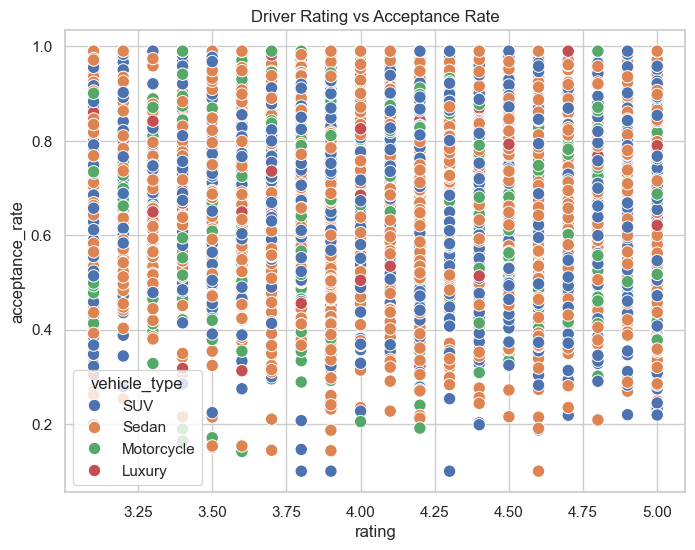

In [74]:
# ==================================================
# Driver Rating vs Acceptance Rate
# ==================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=drivers,
    x="rating",
    y="acceptance_rate",
    hue="vehicle_type",
    s=80
)

plt.title("Driver Rating vs Acceptance Rate")

plt.show()